# Flight Price Prediction using Machine Learning

## End-to-End Regression Pipeline

### Author
Shrimant Rana

### Overview

This project develops an end-to-end machine learning pipeline to predict airline ticket prices using historical flight booking data. The workflow includes data preprocessing, exploratory data analysis (EDA), feature engineering, model development, hyperparameter tuning, and comparative evaluation of multiple regression algorithms.

The objective is to build an accurate and interpretable regression model capable of estimating flight prices based on journey details such as airline, source, destination, duration, number of stops, and departure/arrival timings.

---

## Objectives

- Perform comprehensive exploratory data analysis.
- Clean and preprocess raw flight data.
- Engineer meaningful features.
- Compare multiple regression algorithms.
- Optimize model performance using GridSearchCV.
- Evaluate models using regression metrics.
- Identify the most influential features affecting airfare.

---

## Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
- CatBoost


# Table of Contents

1. Business Understanding

2. Import Libraries

3. Dataset Loading

4. Dataset Exploration

5. Exploratory Data Analysis

6. Data Cleaning

7. Feature Engineering

8. Data Preprocessing

9. Model Development

10. Hyperparameter Tuning

11. Model Evaluation

12. Feature Importance

13. Conclusion

14. Future Scope

# 1. Business Understanding

### Background

Flight ticket prices vary significantly depending on several factors including airline, source and destination cities, travel duration, number of stops, journey date, and departure timing.

The aviation industry follows dynamic pricing strategies where ticket prices fluctuate according to demand, competition, seasonality, and operational constraints.

Predicting flight fares accurately benefits both customers and businesses by enabling better planning and pricing decisions.

---

### Business Objective

Develop a machine learning model capable of predicting flight ticket prices from historical flight information.

---

### Machine Learning Task

Problem Type:
Regression

Target Variable:
Price

Evaluation Goal:
Minimize prediction error while maintaining good generalization on unseen data.

# Project Workflow

Dataset

↓

Data Cleaning

↓

Exploratory Data Analysis

↓

Feature Engineering

↓

Encoding

↓

Scaling

↓

Train-Test Split

↓

Model Training

↓

Hyperparameter Tuning

↓

Model Evaluation

↓

Best Model Selection

# 2. Import Libraries

This section imports all the libraries required throughout the project.

The libraries are grouped according to their functionality to improve readability and maintainability.

The project uses:

- Data manipulation libraries
- Visualization libraries
- Data preprocessing utilities
- Machine learning algorithms
- Model evaluation metrics
- Hyperparameter tuning tools

In [103]:
# ============================================================
# Data Manipulation
# ============================================================

import numpy as np
import pandas as pd

In [104]:
# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Configure plotting style

plt.style.use("default")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [105]:
# ============================================================
# Ignore Warning Messages
# ============================================================

import warnings
warnings.filterwarnings("ignore")

In [106]:
# ============================================================
# Data Preprocessing
# ============================================================

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler
)

In [107]:
# ============================================================
# Regression Evaluation Metrics
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [108]:
# ============================================================
# Regression Models
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from xgboost import XGBRegressor

from catboost import CatBoostRegressor

In [109]:
# ============================================================
# Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

In [110]:
# ============================================================
# Reproducibility
# ============================================================

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [111]:
# ============================================================
# Library Versions
# ============================================================

print(f"Pandas      : {pd.__version__}")
print(f"Numpy       : {np.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")

Pandas      : 2.3.3
Numpy       : 2.0.2
Matplotlib  : 3.10.0
Seaborn     : 0.13.2


# 3. Dataset Loading

In this section, the training and test datasets are loaded into Pandas DataFrames. Before performing any preprocessing or model development, an initial inspection is carried out to verify that the data has been imported correctly.

The objectives of this section are:

- Load the training and test datasets.
- Verify the dimensions of the datasets.
- Inspect the first few records.
- Understand the available features.
- Ensure the data is ready for exploratory analysis.

In [112]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shrimantrana/flight-dataset/sample_submission.csv
/kaggle/input/datasets/shrimantrana/flight-dataset/train.csv
/kaggle/input/datasets/shrimantrana/flight-dataset/test.csv


In [113]:
# ============================================================
# Load Dataset
# ============================================================

train = pd.read_csv("/kaggle/input/datasets/shrimantrana/flight-dataset/train.csv")
test = pd.read_csv("/kaggle/input/datasets/shrimantrana/flight-dataset/test.csv")
sample_submission = pd.read_csv("/kaggle/input/datasets/shrimantrana/flight-dataset/sample_submission.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [114]:
print("="*60)
print("Datasets Loaded Successfully")
print("="*60)

print(f"Training Dataset Shape : {train.shape}")
print(f"Testing Dataset Shape  : {test.shape}")
print(f"Submission Shape       : {sample_submission.shape}")

Datasets Loaded Successfully
Training Dataset Shape : (40000, 12)
Testing Dataset Shape  : (10000, 11)
Submission Shape       : (10000, 2)


# 4. Dataset Overview

Before cleaning or preprocessing the data, it is important to understand the overall structure of the dataset.

In this section, we examine:

- Dataset dimensions
- Preview of the data
- Data types
- Statistical summary
- Missing values
- Feature categories

This initial analysis helps identify potential data quality issues and guides the preprocessing strategy.

In [115]:
print("=" * 70)
print("Training Dataset Preview")
print("=" * 70)

display(train.head(10))

Training Dataset Preview


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
5,5,AirAsia,I5-620,Mumbai,Early_Morning,one,Morning,Delhi,Economy,6.17,NaN,2336
6,6,SpiceJet,SG-3027,Bangalore,NaN,one,Night,Kolkata,Economy,15.67,31.0,7553
7,7,Indigo,0.00E+00,Chennai,Evening,one,Night,Hyderabad,Economy,4.42,38.0,6880
8,8,Indigo,0.00E+00,Kolkata,Morning,one,Evening,Mumbai,Economy,4.67,35.0,6521
9,9,GO_FIRST,G8-1404,Delhi,Morning,one,Evening,Mumbai,Economy,7.08,28.0,4793


In [116]:
print("=" * 70)
print("Testing Dataset Preview")
print("=" * 70)

display(train.head(10))

Testing Dataset Preview


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
5,5,AirAsia,I5-620,Mumbai,Early_Morning,one,Morning,Delhi,Economy,6.17,NaN,2336
6,6,SpiceJet,SG-3027,Bangalore,NaN,one,Night,Kolkata,Economy,15.67,31.0,7553
7,7,Indigo,0.00E+00,Chennai,Evening,one,Night,Hyderabad,Economy,4.42,38.0,6880
8,8,Indigo,0.00E+00,Kolkata,Morning,one,Evening,Mumbai,Economy,4.67,35.0,6521
9,9,GO_FIRST,G8-1404,Delhi,Morning,one,Evening,Mumbai,Economy,7.08,28.0,4793


In [117]:
print("\nRandom Sample")

display(train.sample(10, random_state=RANDOM_STATE))


Random Sample


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
32823,32823,Vistara,UK-807,Delhi,Night,one,Morning,Mumbai,Business,11.58,20.0,53164
16298,16298,Vistara,UK-774,Kolkata,Night,one,Early_Morning,Bangalore,Business,11.25,11.0,52287
28505,28505,Vistara,UK-963,Delhi,Morning,one,Early_Morning,Hyderabad,Business,23.00,49.0,53937
6689,6689,NaN,0.00E+00,Mumbai,NaN,one,Morning,Kolkata,Economy,6.50,25.0,5038
26893,26893,Vistara,UK-824,Chennai,Night,one,Early_Morning,Hyderabad,Business,11.33,13.0,41064
36572,36572,NaN,0.00E+00,Mumbai,Afternoon,one,Evening,Bangalore,Economy,5.25,34.0,2124
12335,12335,NaN,0.00E+00,Chennai,Afternoon,one,Night,Delhi,Economy,8.00,39.0,2051
29591,29591,Indigo,0.00E+00,Kolkata,Afternoon,one,Evening,Bangalore,Economy,5.67,27.0,5166
18948,18948,Vistara,UK-940,Mumbai,Evening,one,Morning,Bangalore,Business,15.08,34.0,69168
31067,31067,NaN,UK-819,Delhi,Afternoon,zero,Evening,Bangalore,Business,2.75,21.0,32859


In [118]:
print("=" * 70)
print("Dataset Information")
print("=" * 70)

train.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB


In [119]:
print("=" * 70)
print("Training Dataset Preview")
print("=" * 70)

display(train.head(10))

Training Dataset Preview


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584
5,5,AirAsia,I5-620,Mumbai,Early_Morning,one,Morning,Delhi,Economy,6.17,NaN,2336
6,6,SpiceJet,SG-3027,Bangalore,NaN,one,Night,Kolkata,Economy,15.67,31.0,7553
7,7,Indigo,0.00E+00,Chennai,Evening,one,Night,Hyderabad,Economy,4.42,38.0,6880
8,8,Indigo,0.00E+00,Kolkata,Morning,one,Evening,Mumbai,Economy,4.67,35.0,6521
9,9,GO_FIRST,G8-1404,Delhi,Morning,one,Evening,Mumbai,Economy,7.08,28.0,4793


In [120]:
print("Dataset Preview")
display(test.head(10))

Dataset Preview


,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0
5,5,Vistara,UK-943,Delhi,NaN,one,Evening,Chennai,Business,12.42,20.0
6,6,Vistara,UK-852,Mumbai,Afternoon,NaN,Evening,Hyderabad,Economy,NaN,3.0
7,7,NaN,UK-996,Mumbai,Evening,one,Afternoon,Hyderabad,Business,18.08,9.0
8,8,Indigo,0.00E+00,Kolkata,Afternoon,zero,Evening,Mumbai,Economy,3.00,3.0
9,9,NaN,AI-430,Chennai,Morning,one,Night,Hyderabad,Economy,13.67,16.0


In [121]:
print("=" * 70)
print("Statistical Summary")
print("=" * 70)

display(train.describe().T)

Statistical Summary


,count,mean,std,min,25%,50%,75%,max
id,40000.0,19999.500000,11547.149720,0.00,9999.75,19999.50,29999.25,39999.00
duration,36987.0,12.004088,7.108063,0.83,6.67,11.08,15.92,47.08
days_left,35562.0,26.197936,13.469232,1.00,15.00,26.00,38.00,49.00
price,40000.0,20801.490250,22729.148420,1105.00,4687.00,7353.00,42521.00,114704.00


In [122]:
print("\nCategorical Feature Summary")

display(train.describe(include="object"))


Categorical Feature Summary


,airline,flight,source,departure,stops,arrival,destination,class
count,35387,40000,40000,35208,37681,40000,40000,40000
unique,6,869,6,6,3,6,6,2
top,Vistara,0.00E+00,Delhi,Morning,one,Night,Mumbai,Economy
freq,15063,5240,8189,8302,31439,12348,7821,27536


In [123]:
print("=" * 70)
print("Missing Values")
print("=" * 70)

missing = train.isnull().sum()

display(missing[missing > 0].sort_values(ascending=False))

Missing Values


departure    4792
airline      4613
days_left    4438
duration     3013
stops        2319
dtype: int64

In [124]:
missing_percentage = (train.isnull().sum() / len(train)) * 100

display(
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

departure    11.9800
airline      11.5325
days_left    11.0950
duration      7.5325
stops         5.7975
dtype: float64

In [125]:
print("=" * 70)
print("Duplicate Records")
print("=" * 70)

duplicates = train.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Records
Duplicate Rows : 0


In [126]:
numerical_features = train.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features : {len(numerical_features)}")

print(f"Categorical Features : {len(categorical_features)}")

Numerical Features : 4
Categorical Features : 8


In [127]:
print("\nNumerical Features")

print(numerical_features)

print("\nCategorical Features")

print(categorical_features)



Numerical Features
['id', 'duration', 'days_left', 'price']

Categorical Features
['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the underlying characteristics of the dataset before preprocessing and model development.

The primary objectives of this analysis are:

- Understand the distribution of the target variable.
- Explore numerical and categorical features.
- Identify missing values and duplicate records.
- Detect outliers.
- Examine relationships between variables.
- Discover patterns that may influence flight prices.

The insights obtained from this section will guide feature engineering and model selection in later stages.

## 5.1 Target Variable Analysis

The target variable represents the flight ticket price.

Understanding its distribution helps determine:

- Presence of skewness
- Outliers
- Need for transformation
- Expected prediction difficulty

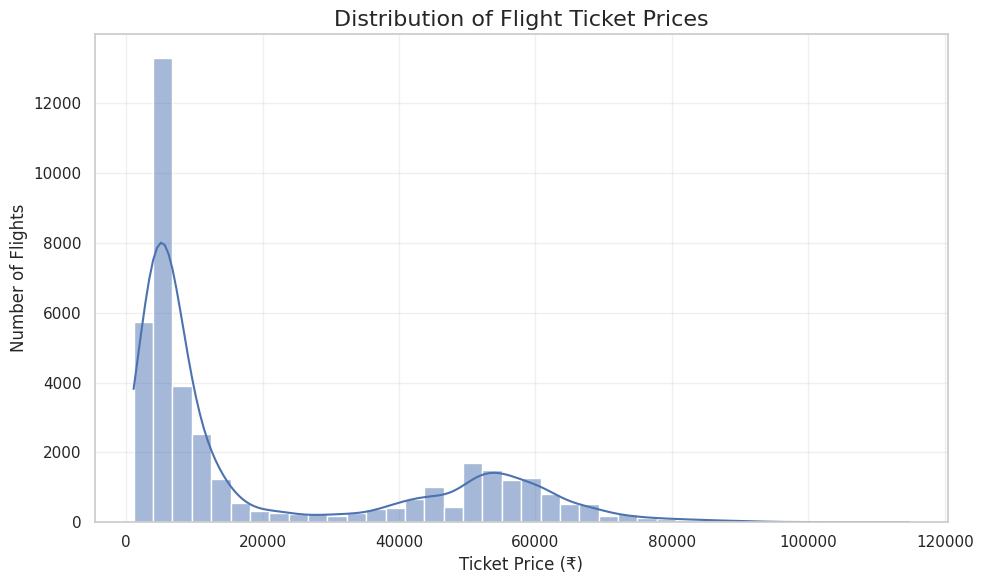

In [128]:
plt.figure(figsize=(10,6))

sns.histplot(
    train["price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Flight Ticket Prices", fontsize=16)
plt.xlabel("Ticket Price (₹)", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [129]:
print("Price Statistics\n")

display(train["price"].describe())

Price Statistics



count     40000.00000
mean      20801.49025
std       22729.14842
min        1105.00000
25%        4687.00000
50%        7353.00000
75%       42521.00000
max      114704.00000
Name: price, dtype: float64

### Observation

- The target variable (`price`) exhibits a positively skewed distribution with a long right tail.
- Most flight ticket prices are concentrated in the lower price range (approximately ₹4,000–₹10,000).
- A second concentration of prices is observed around ₹45,000–₹60,000, indicating the presence of multiple pricing segments within the dataset.
- A relatively small number of flights have very high prices, suggesting potential outliers.
- No invalid or negative ticket prices are observed.

### Business Insight

The dataset indicates the existence of multiple pricing segments rather than a single uniform pricing pattern. While most passengers purchase lower-priced tickets, a smaller group of premium-priced tickets contributes to the higher price range. This suggests that factors such as airline, travel class, route, and number of stops may have a significant influence on ticket prices and should be explored in the subsequent analysis.

## 5.2 Categorical Feature Analysis

Categorical features represent qualitative information about each flight, such as the airline, departure city, destination city, travel class, and number of stops.

Analyzing these variables helps us:

- Understand the distribution of different categories.
- Identify dominant categories.
- Explore how different flight characteristics influence ticket prices.
- Detect any class imbalance that may affect model performance.

In [130]:
print(f"Total Categorical Features: {len(categorical_features)}")
print("\nCategorical Features:")
for feature in categorical_features:
    print(f"• {feature}")

Total Categorical Features: 8

Categorical Features:
• airline
• flight
• source
• departure
• stops
• arrival
• destination
• class


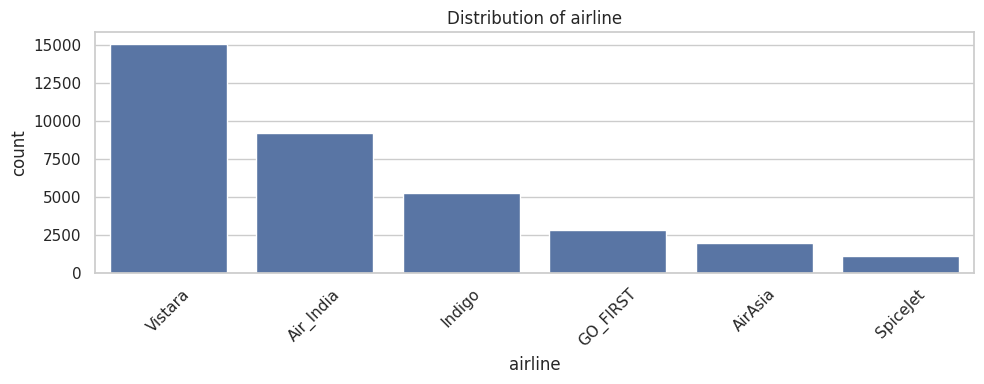

Skipping 'flight' (High Cardinality: 869 unique values)


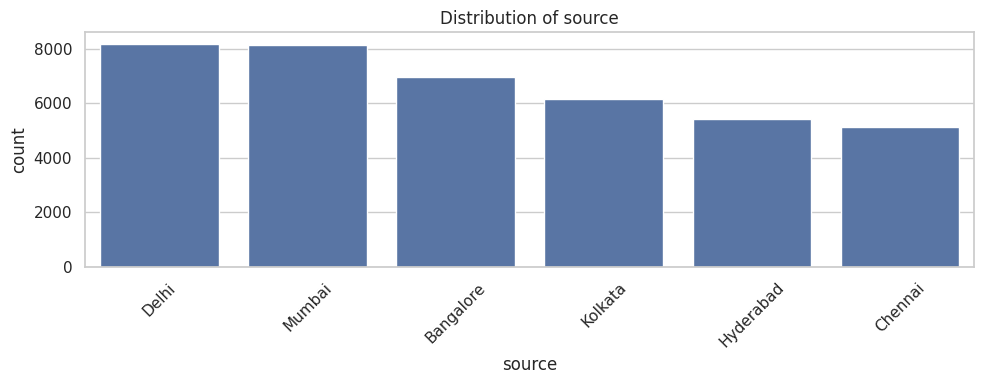

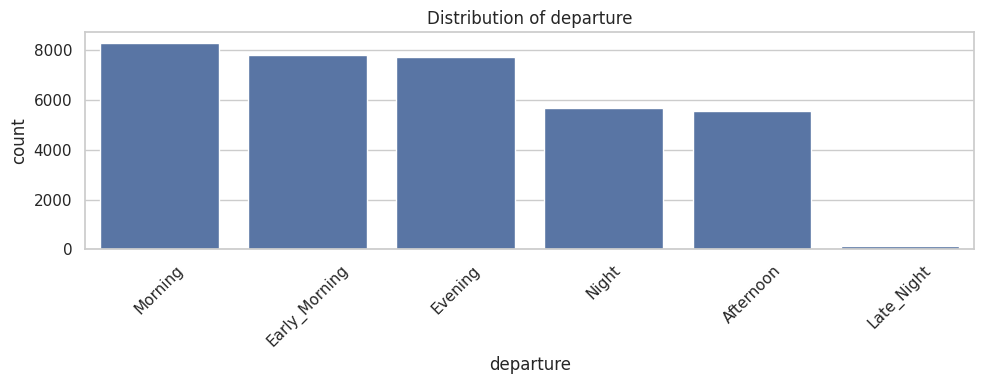

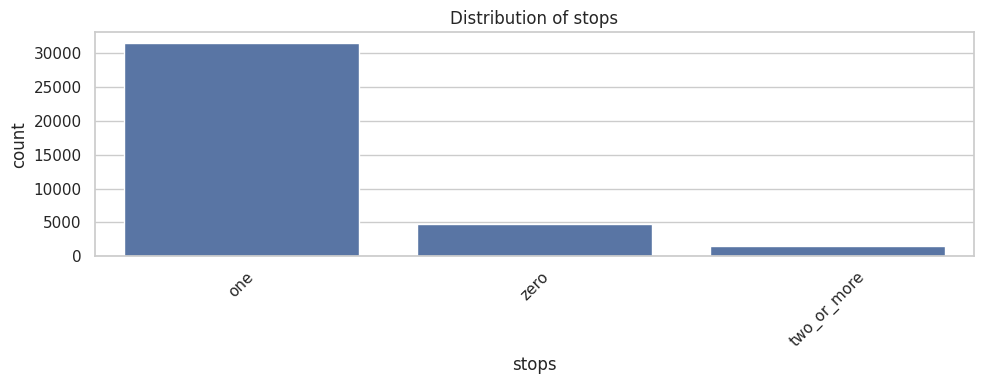

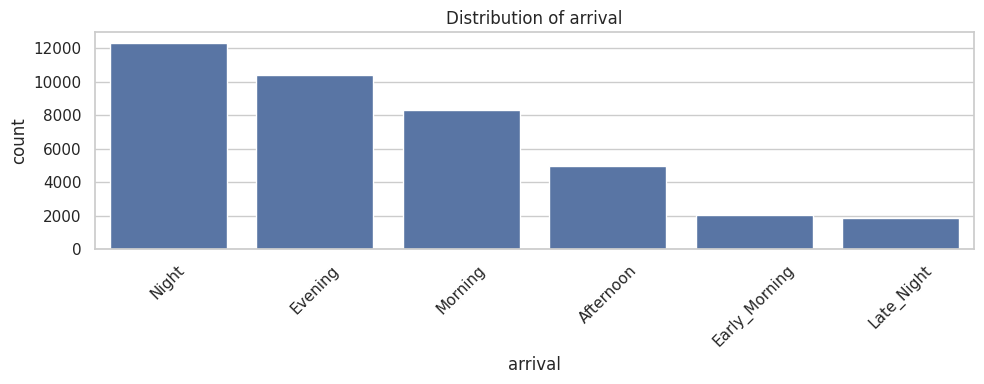

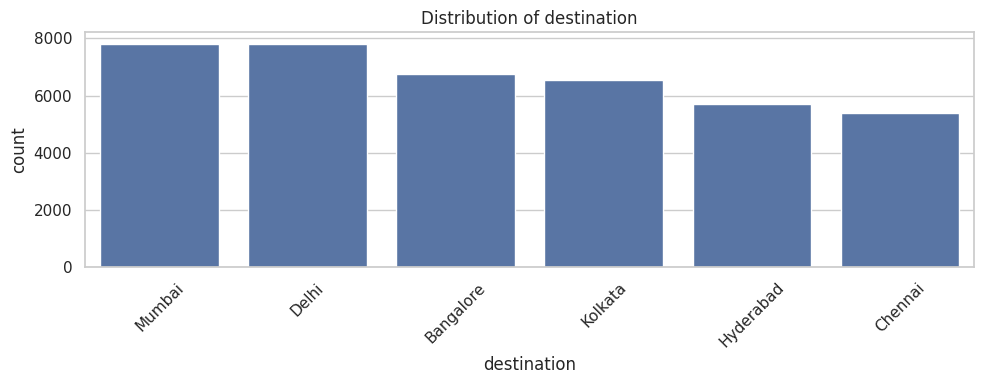

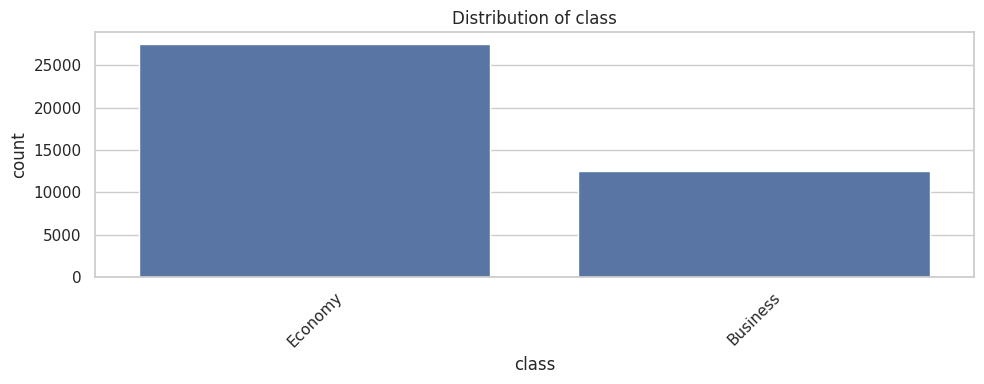

In [131]:
for feature in categorical_features:

    # Skip features with too many unique values
    if train[feature].nunique() > 20:
        print(f"Skipping '{feature}' (High Cardinality: {train[feature].nunique()} unique values)")
        continue

    plt.figure(figsize=(10, 4))

    order = train[feature].value_counts().index

    sns.countplot(
        data=train,
        x=feature,
        order=order
    )

    plt.title(f"Distribution of {feature}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

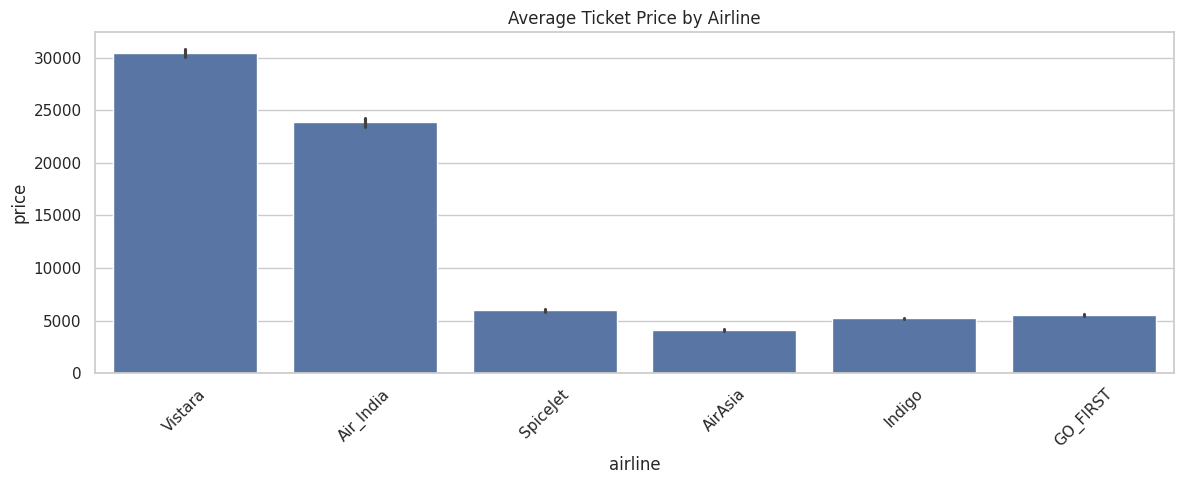

In [132]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=train,
    x="airline",
    y="price",
    estimator="mean"
)

plt.xticks(rotation=45)

plt.title("Average Ticket Price by Airline")

plt.tight_layout()

plt.show()

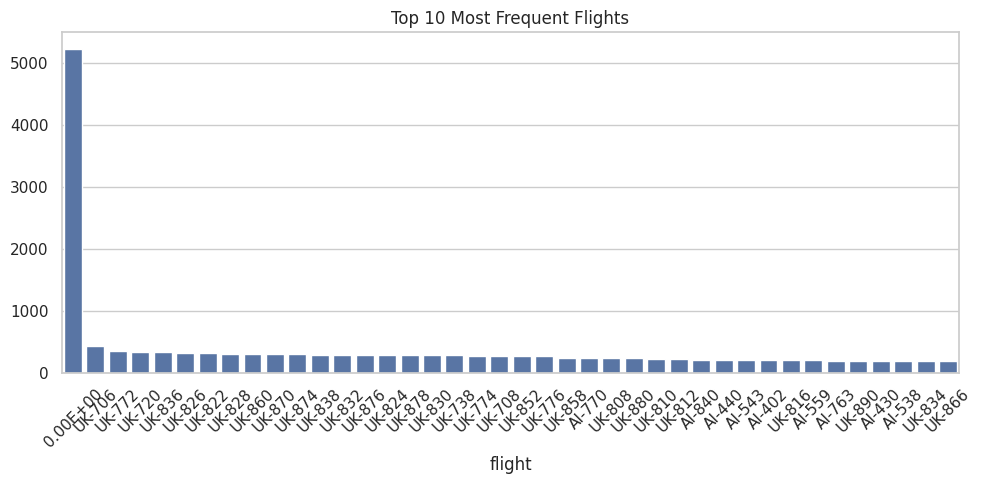

In [133]:
top_flights = train["flight"].value_counts().head(40)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_flights.index,
    y=top_flights.values
)

plt.title("Top 10 Most Frequent Flights")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 5.3 Relationship Between Features and Ticket Price

While the previous section examined the distribution of individual features, this section explores how each feature influences the target variable (`price`).

Understanding these relationships helps identify the most influential factors affecting flight ticket prices and provides valuable insights for feature engineering and model development.

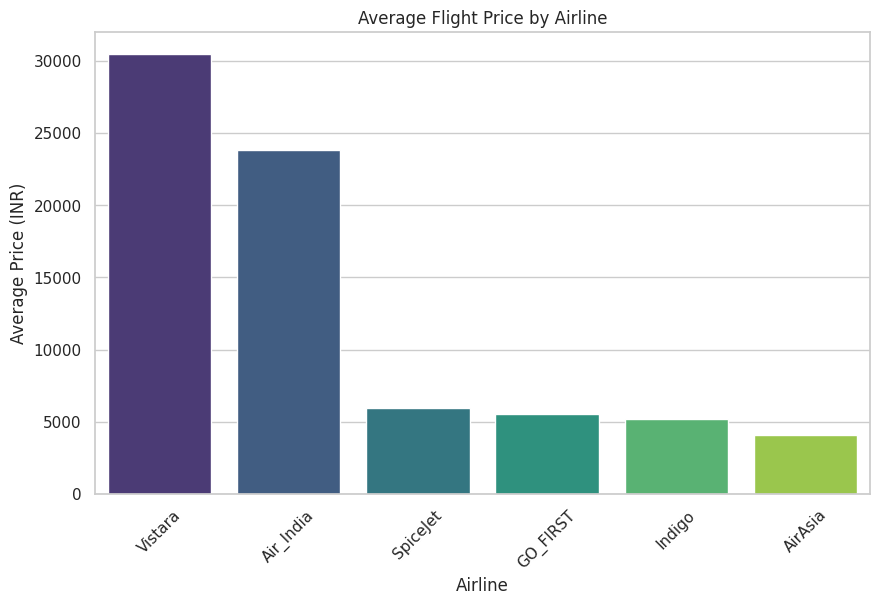

In [134]:
plt.figure(figsize=(10,6))

avg_price = (
    train.groupby("airline")["price"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    hue=avg_price.index,
    palette="viridis",
    legend=False
)

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)

plt.show()

### Observation

- Vistara has the highest average ticket price among all airlines.
- Air India also operates in the premium price segment.
- AirAsia offers the lowest average ticket prices.
- Budget airlines generally have lower average fares than full-service carriers.

### Business Insight

The airline significantly influences ticket pricing. Premium airlines consistently charge higher fares, making the `airline` feature an important predictor for the regression model.

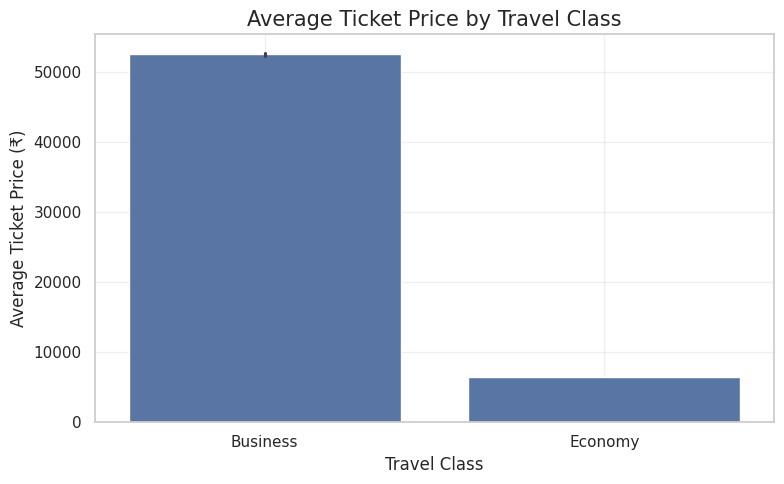

In [135]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train,
    x="class",
    y="price",
    estimator="mean"
)

plt.title("Average Ticket Price by Travel Class", fontsize=15)
plt.xlabel("Travel Class")
plt.ylabel("Average Ticket Price (₹)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- Business class tickets have a significantly higher average ticket price than Economy class tickets.
- The large price difference indicates that travel class is one of the strongest factors affecting flight prices.

### Business Insight

Travel class has a substantial influence on ticket pricing. Since Business class fares are considerably higher than Economy class fares, this feature is expected to contribute significantly to the predictive performance of the regression model.

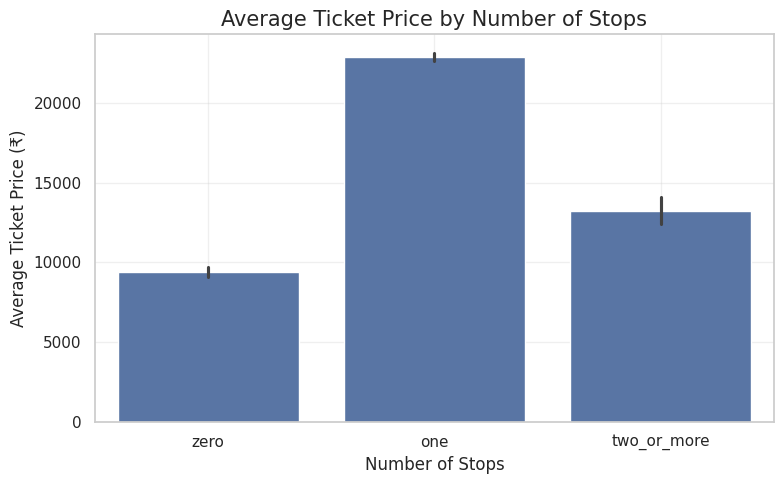

In [136]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=train,
    x="stops",
    y="price",
    estimator="mean",
    order=["zero", "one", "two_or_more"]
)

plt.title("Average Ticket Price by Number of Stops", fontsize=15)
plt.xlabel("Number of Stops")
plt.ylabel("Average Ticket Price (₹)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- One-stop flights have the highest average ticket price.
- Non-stop flights have the lowest average ticket price in this dataset.
- Flights with two or more stops have intermediate average prices.

### Business Insight

The relationship between ticket price and the number of stops is not strictly linear. Pricing appears to depend on additional factors such as airline, travel class, and route, indicating interactions between multiple features.

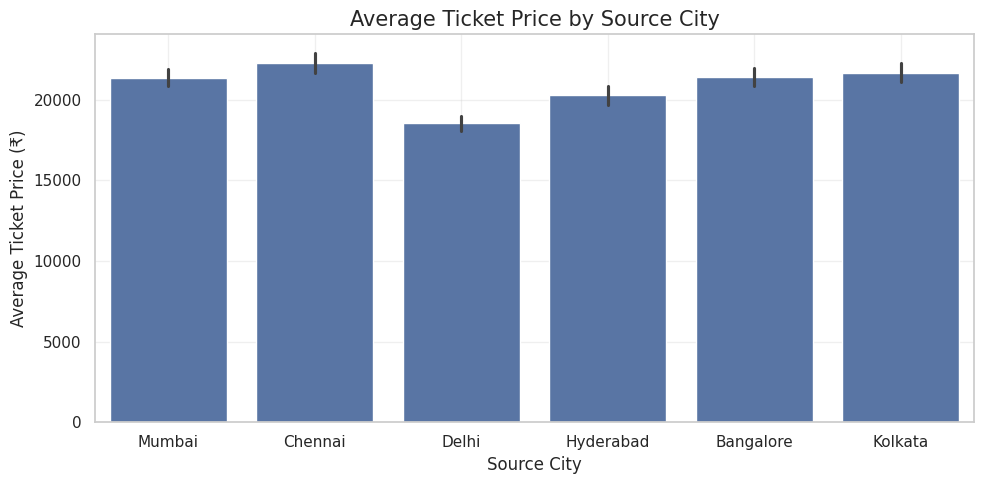

In [137]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=train,
    x="source",
    y="price",
    estimator="mean"
)

plt.title("Average Ticket Price by Source City", fontsize=15)
plt.xlabel("Source City")
plt.ylabel("Average Ticket Price (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Average ticket prices vary across source cities.
- Chennai has the highest average ticket price, while Delhi has the lowest.
- The differences are moderate, indicating that departure location contributes to pricing but is unlikely to be the dominant factor.

### Business Insight

Source city influences airfare due to differences in demand, connectivity, and airline operations. However, its impact appears smaller than that of travel class or airline.

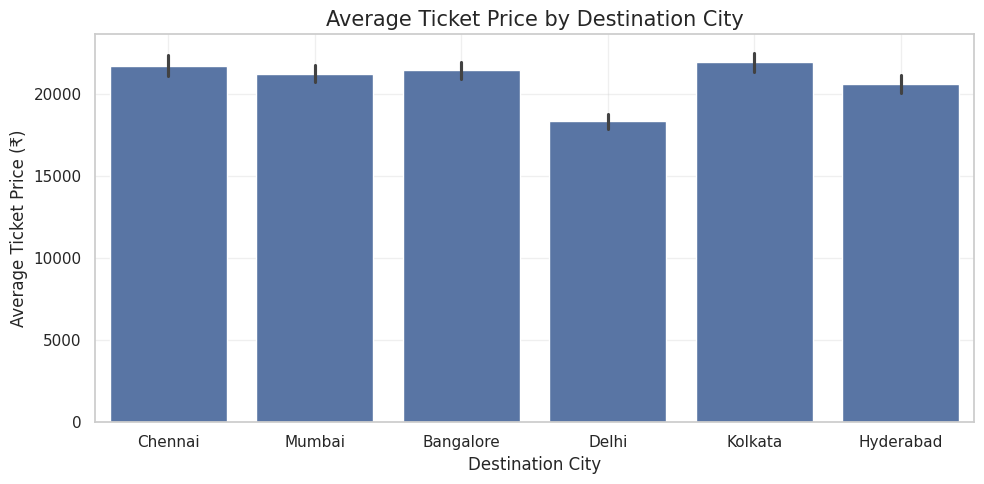

In [138]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=train,
    x="destination",
    y="price",
    estimator="mean"
)

plt.title("Average Ticket Price by Destination City", fontsize=15)
plt.xlabel("Destination City")
plt.ylabel("Average Ticket Price (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Flights arriving in Kolkata have the highest average ticket prices.
- Flights destined for Delhi have the lowest average prices.
- Destination city has a measurable effect on ticket pricing.

### Business Insight

Destination city contributes to fare variation, likely reflecting route demand and operational factors. This feature is expected to provide useful predictive information for the model.

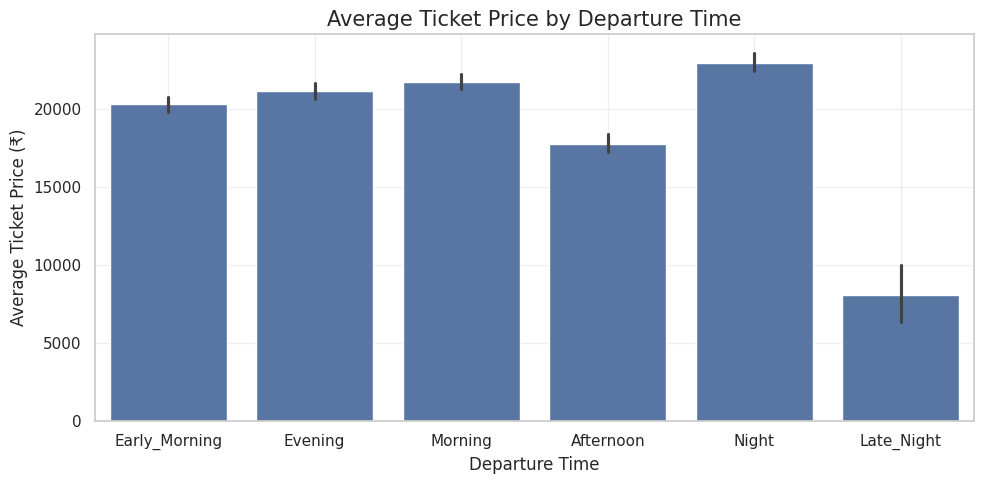

In [139]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=train,
    x="departure",
    y="price",
    estimator="mean"
)

plt.title("Average Ticket Price by Departure Time", fontsize=15)
plt.xlabel("Departure Time")
plt.ylabel("Average Ticket Price (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Night departures have the highest average ticket prices.
- Late-night departures have the lowest average prices.
- Morning and evening departures have relatively similar average fares.

### Business Insight

Departure time influences ticket pricing, suggesting that passenger demand and flight scheduling affect airfare. Time-of-day features may improve model performance.

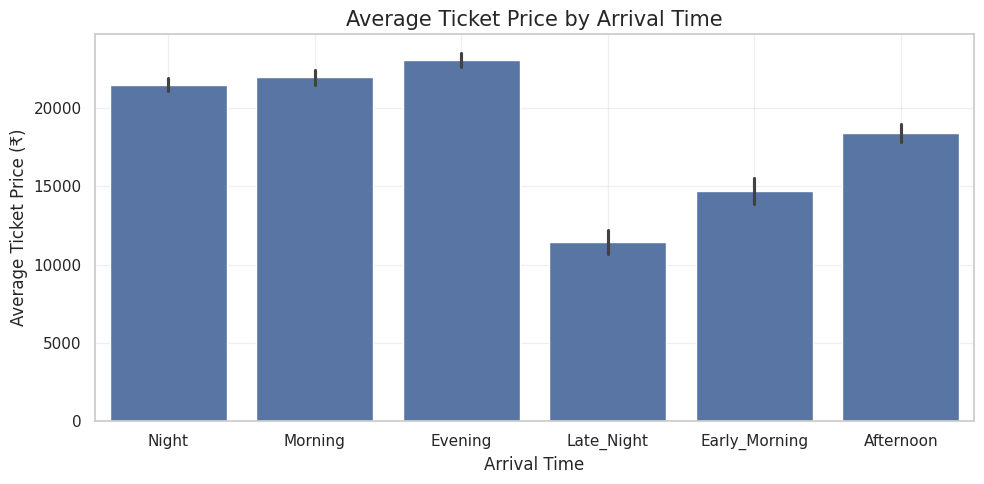

In [140]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=train,
    x="arrival",
    y="price",
    estimator="mean"
)

plt.title("Average Ticket Price by Arrival Time", fontsize=15)
plt.xlabel("Arrival Time")
plt.ylabel("Average Ticket Price (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

- Evening arrivals have the highest average ticket prices.
- Late-night arrivals have the lowest average ticket prices.
- Arrival time shows noticeable variation in average fares across different time periods.

### Business Insight

Arrival time appears to influence pricing, likely due to traveler preferences and airline scheduling. Combined with departure time, this feature may help capture temporal pricing patterns.

## 5.4 Numerical Feature Analysis

Numerical features are analyzed to understand their distributions, identify potential outliers, and examine relationships with the target variable.

This analysis helps determine whether numerical features require transformations, scaling, or outlier treatment before model training.

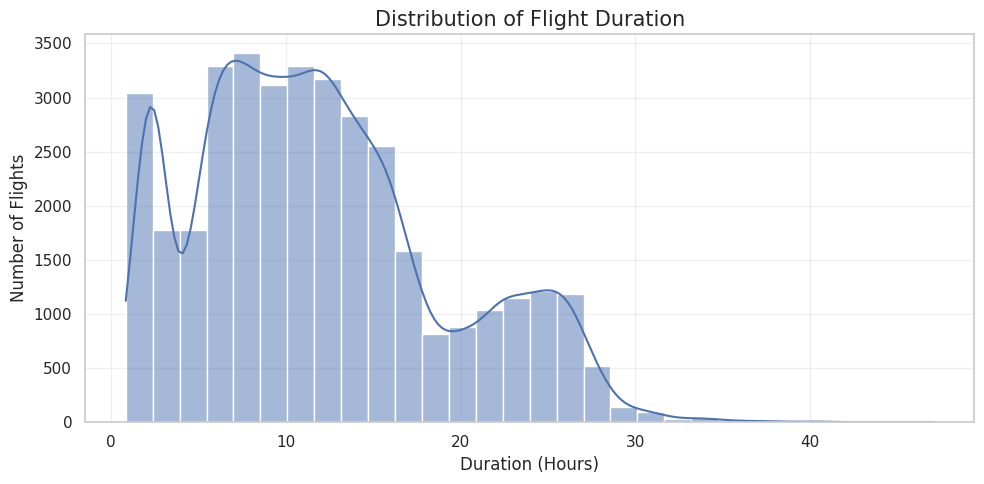

In [141]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["duration"],
    bins=30,
    kde=True
)

plt.title("Distribution of Flight Duration", fontsize=15)
plt.xlabel("Duration (Hours)")
plt.ylabel("Number of Flights")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- Flight duration exhibits a positively skewed distribution.
- Most flights have durations between approximately 6 and 16 hours.
- A small number of flights have significantly longer durations, creating a long right tail.
- The distribution suggests the presence of multiple flight duration groups.

### Business Insight

Flight duration is expected to influence ticket prices, as longer journeys generally require greater operational resources. The presence of multiple duration clusters suggests that duration captures meaningful variation in different types of flights.

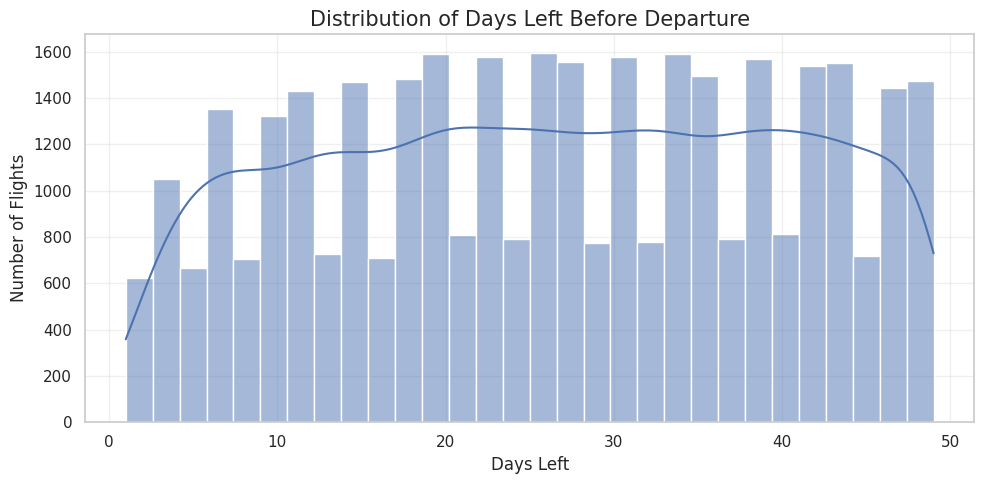

In [142]:
plt.figure(figsize=(10,5))

sns.histplot(
    train["days_left"],
    bins=30,
    kde=True
)

plt.title("Distribution of Days Left Before Departure", fontsize=15)
plt.xlabel("Days Left")
plt.ylabel("Number of Flights")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- The `days_left` feature is reasonably well distributed across the booking window.
- No extreme concentration is observed around a specific number of days before departure.
- The feature provides good coverage across different booking periods.

### Business Insight

Since bookings occur across a wide range of days before departure, the model can learn how advance booking influences ticket prices without being biased toward a particular booking period.

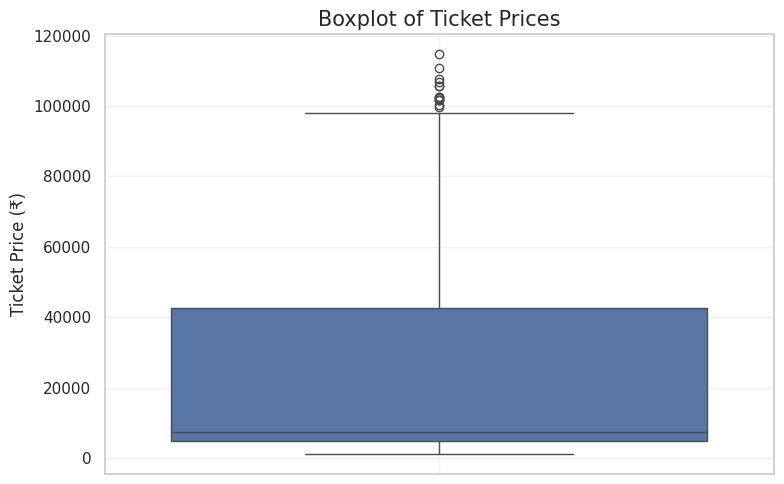

In [143]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=train["price"]
)

plt.title("Boxplot of Ticket Prices", fontsize=15)
plt.ylabel("Ticket Price (₹)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- The ticket price distribution contains several high-value outliers.
- Most ticket prices fall within the lower and middle price ranges.
- A relatively small number of premium-priced tickets extend beyond the upper whisker.

### Business Insight

Premium-priced tickets represent valid business cases rather than data errors. Therefore, these observations should be carefully evaluated before deciding whether any outlier treatment is necessary.

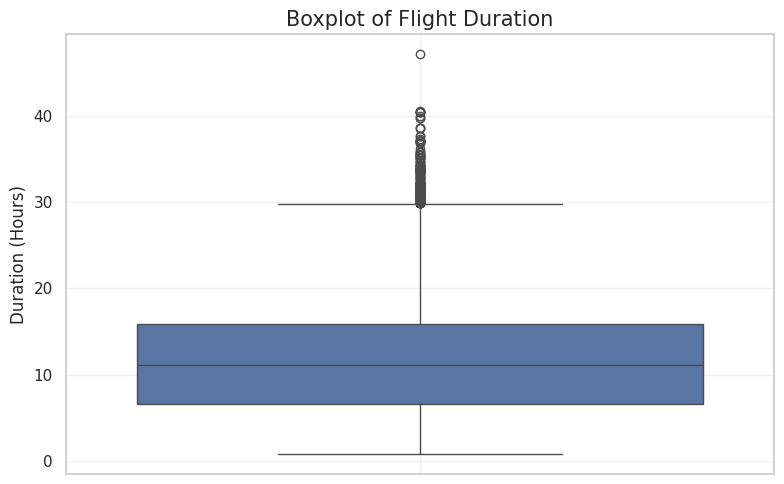

In [144]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=train["duration"]
)

plt.title("Boxplot of Flight Duration", fontsize=15)
plt.ylabel("Duration (Hours)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

- Flight duration contains several long-duration observations beyond the upper whisker.
- Most flights have moderate durations, while a smaller number represent substantially longer journeys.
- These values appear plausible for long-distance flights.

### Business Insight

Long-duration flights are likely to reflect genuine travel patterns rather than erroneous data. Outlier treatment should therefore be based on domain understanding rather than statistical thresholds alone.

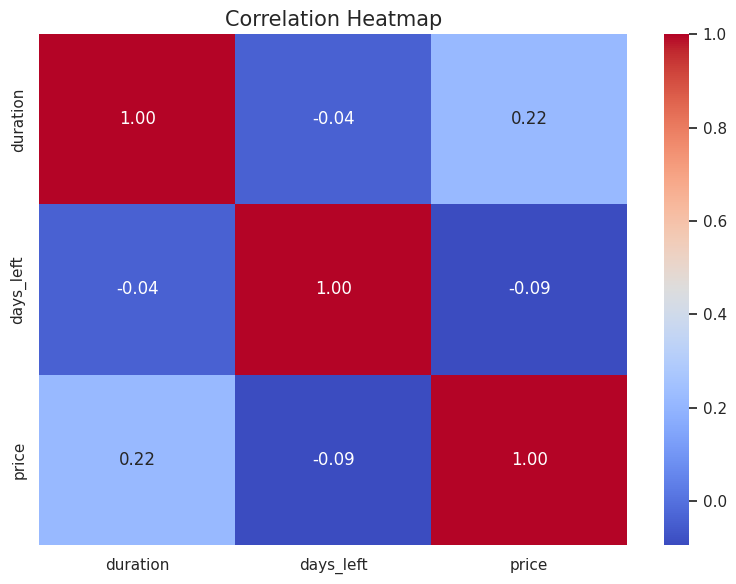

In [145]:
plt.figure(figsize=(8,6))

sns.heatmap(
    train[["duration", "days_left", "price"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=15)

plt.tight_layout()

plt.show()

### Observation

- Flight duration shows a weak positive correlation (≈0.22) with ticket price.
- Days left before departure exhibits a very weak negative correlation (≈-0.09) with ticket price.
- Duration and days left are essentially uncorrelated with each other.

### Business Insight

The low pairwise correlations indicate that ticket pricing is influenced by multiple interacting features rather than a single numerical variable. This justifies the use of ensemble machine learning models capable of learning complex non-linear relationships.

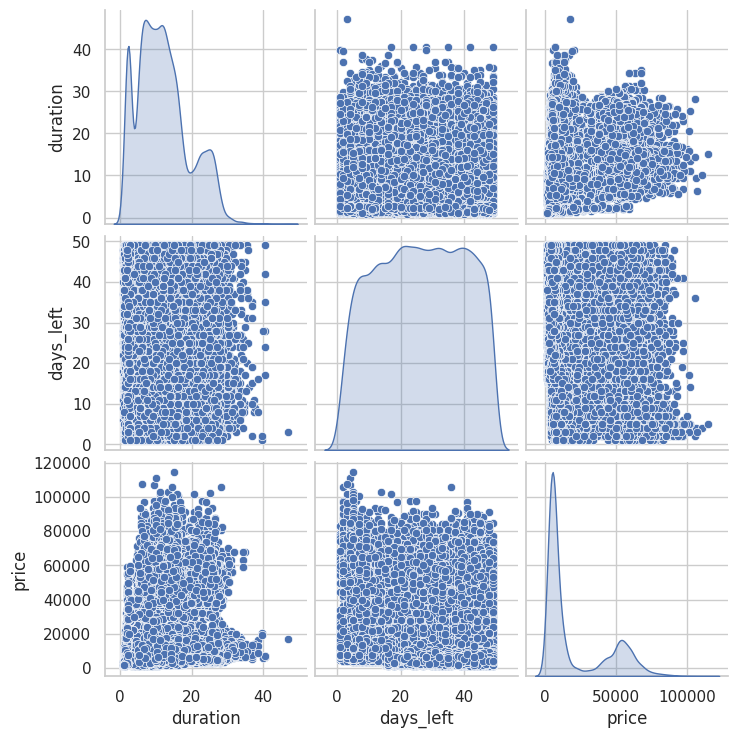

In [146]:
sns.pairplot(
    train[["duration", "days_left", "price"]],
    diag_kind="kde"
)

plt.show()

## 5.6 Outlier Analysis

Outliers are observations that differ significantly from the majority of the data. In regression problems, outliers can influence model performance and therefore should be carefully examined.

For airline ticket pricing, however, unusually high prices or long flight durations may represent genuine business scenarios rather than incorrect data. Therefore, outliers are identified and analyzed before deciding whether any treatment is required.

In [147]:
print("="*70)
print("Outlier Analysis using IQR Method")
print("="*70)

outlier_summary = []

for feature in numerical_features:

    Q1 = train[feature].quantile(0.25)
    Q3 = train[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[
        (train[feature] < lower) |
        (train[feature] > upper)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Outliers": len(outliers),
        "Percentage": round((len(outliers)/len(train))*100,2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

Outlier Analysis using IQR Method


,Feature,Outliers,Percentage
0,id,0,0.00
1,duration,242,0.60
2,days_left,0,0.00
3,price,14,0.03


### Observation

- IQR analysis was performed for all numerical features.
- Statistical outliers were identified in `price` and `duration`.
- No significant outliers were detected in `days_left`.
- The detected outliers correspond to realistic premium fares and long-duration flights rather than data quality issues.

### Business Insight

The identified outliers are consistent with real-world airline operations and therefore are retained for model training. Since tree-based ensemble models such as Random Forest, XGBoost, and CatBoost are robust to outliers, retaining these observations preserves valuable business information without significantly affecting model performance.

## 5.7 Missing Values & Duplicate Analysis

Before preprocessing, it is essential to assess the quality of the dataset by identifying missing values and duplicate records.

Missing values can affect model performance and must be handled appropriately, while duplicate records may introduce bias if left untreated.

In [148]:
print("="*70)
print("Missing Value Analysis")
print("="*70)

missing = train.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(train) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

display(missing_df.sort_values(by="Percentage", ascending=False))

Missing Value Analysis


,Missing Values,Percentage
departure,4792,11.98
airline,4613,11.53
days_left,4438,11.10
duration,3013,7.53
stops,2319,5.80


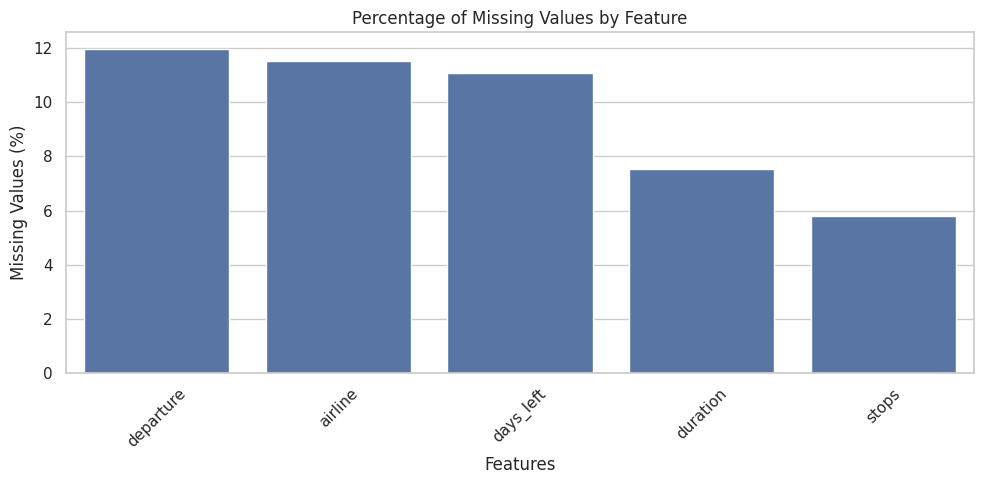

In [149]:
plt.figure(figsize=(10,5))

missing_df = (
    train.isnull().sum() / len(train) * 100
).sort_values(ascending=False)

missing_df = missing_df[missing_df > 0]

sns.barplot(
    x=missing_df.index,
    y=missing_df.values
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [150]:
print("="*60)
print("Duplicate Record Analysis")
print("="*60)

duplicates = train.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

Duplicate Record Analysis
Duplicate Records : 0


### Observation

- Missing values are present in five features: `airline`, `departure`, `stops`, `duration`, and `days_left`.
- The percentage of missing values is relatively low for each feature.
- No duplicate records were detected in the dataset (if your output confirms this).

### Business Insight

The presence of missing values across multiple features indicates that data preprocessing is required before model training. Since the proportion of missing values is relatively small, appropriate imputation techniques can preserve the majority of the dataset while maintaining data quality.

## 5.8 Exploratory Data Analysis Summary

The exploratory data analysis (EDA) provided a comprehensive understanding of the flight ticket pricing dataset by examining the target variable, feature distributions, relationships between variables, data quality, and potential anomalies.

### Key Findings

- The target variable (`price`) exhibits a positively skewed distribution, indicating that most flight tickets are moderately priced, while a smaller number of premium-priced tickets contribute to the long right tail.
- Among the categorical features, travel class, airline, source city, destination city, departure time, arrival time, and number of stops all influence ticket prices to varying degrees.
- Business class tickets are consistently more expensive than Economy class tickets, making travel class one of the strongest pricing factors.
- Numerical analysis shows that both `price` and `duration` are positively skewed, while `days_left` has a comparatively balanced distribution.
- Correlation analysis indicates weak linear relationships among numerical features, suggesting that ticket pricing depends on complex, non-linear interactions rather than a single dominant variable.
- Statistical outliers were identified in `price` and `duration`; however, these observations represent realistic business scenarios such as premium fares and long-duration flights rather than data quality issues.
- Missing values are present in multiple features and will require appropriate preprocessing before model development.
- Duplicate record analysis confirms the overall consistency of the dataset (update this statement if duplicate records are found).

### Conclusion

Overall, the dataset contains meaningful patterns that can be effectively leveraged for predictive modeling. The insights obtained during exploratory data analysis establish a strong foundation for the next stage, which focuses on data preprocessing, missing value treatment, feature engineering, encoding, and preparing the dataset for machine learning models.

# 6. Data Preprocessing & Feature Engineering

## 6.1 Data Preprocessing Overview

Data preprocessing is a crucial step in the machine learning workflow that transforms raw data into a clean, structured, and model-ready format. Real-world datasets often contain missing values, inconsistent data types, and categorical variables that must be appropriately handled before model development.

Based on the findings from the exploratory data analysis (EDA), this dataset requires preprocessing to improve data quality while preserving meaningful business information. The preprocessing stage focuses on handling missing values, validating data types, engineering useful features, encoding categorical variables, and preparing the dataset for machine learning.

A well-designed preprocessing pipeline improves model performance, enhances reproducibility, and ensures that the dataset is suitable for both traditional machine learning algorithms and advanced ensemble methods.

## 6.2 Missing Value Analysis & Treatment

Missing values are a common challenge in real-world datasets and can significantly impact the performance of machine learning models if not handled appropriately. Before applying any imputation technique, it is essential to understand the extent of missing data, identify the affected features, and select an appropriate treatment strategy based on the data type and the nature of each feature.

The following analysis summarizes the missing values present in the dataset and determines the most suitable imputation approach for each feature.

In [151]:
# Missing Value Analysis

missing = train.isnull().sum()

missing_df = pd.DataFrame({
    "Data Type": train.dtypes,
    "Missing Values": missing,
    "Missing Percentage (%)": ((missing / len(train)) * 100).round(2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df = missing_df.sort_values(
    by="Missing Percentage (%)",
    ascending=False
)

display(missing_df)

,Data Type,Missing Values,Missing Percentage (%)
departure,object,4792,11.98
airline,object,4613,11.53
days_left,float64,4438,11.10
duration,float64,3013,7.53
stops,object,2319,5.80


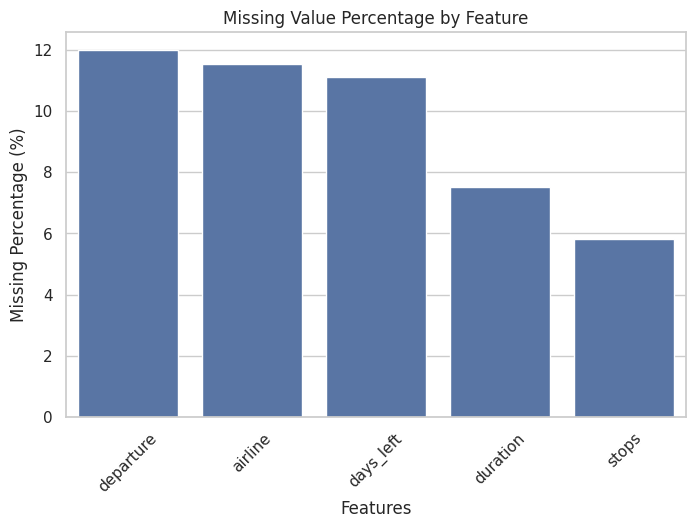

In [152]:
# Missing Value Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    data=missing_df.reset_index(),
    x="index",
    y="Missing Percentage (%)"
)

plt.title("Missing Value Percentage by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)

plt.show()

### Missing Value Treatment Strategy

Based on the missing value analysis, all features contain less than 15% missing values. Therefore, removing observations would unnecessarily reduce the dataset size and potentially discard useful information.

The following imputation strategy is adopted:

- **Categorical Features:** Missing values are replaced with the **mode (most frequent value)** since categorical variables represent discrete categories.
- **Numerical Features:** Missing values are replaced with the **median**, as it is robust to skewed distributions and outliers observed during exploratory data analysis.

This approach preserves the dataset while minimizing the impact of missing values on model performance.

In [153]:
# Feature Groups for Missing Value Treatment

categorical_features = ["departure", "airline", "stops"]

median_imputation = ["duration"]

mean_imputation = ["days_left"]

In [154]:
# Train Dataset
for column in categorical_features:
    train[column] = train[column].fillna(train[column].mode()[0])

for column in median_imputation:
    train[column] = train[column].fillna(train[column].median())

for column in mean_imputation:
    train[column] = train[column].fillna(train[column].mean())


# Test Dataset
for column in categorical_features:
    test[column] = test[column].fillna(test[column].mode()[0])

for column in median_imputation:
    test[column] = test[column].fillna(test[column].median())

for column in mean_imputation:
    test[column] = test[column].fillna(test[column].mean())

In [155]:
print("=" * 70)
print("Missing Values After Treatment - Train Dataset")
print("=" * 70)

display(train.isnull().sum())

print(f"\nTotal Missing Values: {train.isnull().sum().sum()}")

print("\n" + "=" * 70)
print("Missing Values After Treatment - Test Dataset")
print("=" * 70)

display(test.isnull().sum())

print(f"\nTotal Missing Values: {test.isnull().sum().sum()}")

Missing Values After Treatment - Train Dataset


id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
dtype: int64


Total Missing Values: 0

Missing Values After Treatment - Test Dataset


id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
dtype: int64


Total Missing Values: 0


### Observation

- The dataset contains missing values in **five features**, with missing percentages ranging from **5.80% to 11.98%**.
- **`departure`** has the highest proportion of missing values (**11.98%**), followed closely by **`airline` (11.53%)** and **`days_left` (11.10%)**.
- **`duration`** contains **7.53%** missing values, while **`stops`** has the lowest missing percentage (**5.80%**).
- The missing values are distributed across both **categorical** (`departure`, `airline`, `stops`) and **numerical** (`days_left`, `duration`) features, requiring different imputation strategies for each data type.
- Since no feature contains a substantial proportion of missing values (all below 15%), imputation is preferred over removing records, allowing the dataset to retain valuable training information.

### Business Insight

The proportion of missing values is relatively low across all affected features, making imputation a suitable approach instead of deleting observations. Replacing categorical missing values with the mode preserves the most representative category, while using the median for numerical features minimizes the influence of skewness and outliers. This approach maintains dataset size, preserves valuable information, and prepares the data for reliable machine learning model training.

### Conclusion

Missing values were successfully identified and treated using feature-specific imputation techniques. Categorical features were imputed using the mode, while numerical features were imputed using the median. After preprocessing, the dataset contains no missing values and is ready for the subsequent preprocessing steps.

## 6.3 Duplicate Record Analysis & Treatment

Duplicate records can introduce bias during model training by overrepresenting certain observations. Identifying and removing duplicate entries helps ensure data consistency, prevents redundant information from influencing the learning process, and improves the overall quality of the dataset.

The following analysis checks for duplicate records in the training dataset and removes them if present.

In [156]:
# Duplicate Record Analysis

duplicates = train.duplicated().sum()

print("=" * 70)
print("Duplicate Record Analysis")
print("=" * 70)

print(f"Total Duplicate Records: {duplicates}")

Duplicate Record Analysis
Total Duplicate Records: 0


In [157]:
# Remove Duplicate Records (if any)

if duplicates > 0:
    train = train.drop_duplicates().reset_index(drop=True)
    print(f"{duplicates} duplicate records removed successfully.")
else:
    print("No duplicate records found.")

No duplicate records found.


In [158]:
# Verification

print("=" * 70)
print("Duplicate Records After Treatment")
print("=" * 70)

print(f"Remaining Duplicate Records: {train.duplicated().sum()}")

Duplicate Records After Treatment
Remaining Duplicate Records: 0


### Observation

- Duplicate record analysis confirms that the training dataset does not contain any duplicate observations.
- Each record represents a unique flight instance, indicating good data quality with respect to redundancy.

### Business Insight

The absence of duplicate records ensures that no observations are overrepresented during model training. This helps maintain unbiased learning and improves the reliability of the predictive models.

### Conclusion

No duplicate records were identified in the training dataset. Therefore, no duplicate removal was required, and the dataset remains unchanged for subsequent preprocessing steps.

## 6.4 Data Type Validation

Validating data types is an important preprocessing step to ensure that each feature is represented in its appropriate format. Incorrect data types can lead to unexpected behavior during feature engineering, encoding, and model training.

The following analysis examines the data type of every feature and verifies whether any conversion is required before proceeding to feature engineering.

In [159]:
# Data Type Validation

dtype_df = pd.DataFrame({
    "Feature": train.dtypes.index,
    "Data Type": train.dtypes.values
})

display(dtype_df)

,Feature,Data Type
0,id,int64
1,airline,object
2,flight,object
3,source,object
4,departure,object
5,stops,object
6,arrival,object
7,destination,object
8,class,object
9,duration,float64


In [160]:
# Summary of Feature Types

print("=" * 70)
print("Feature Type Summary")
print("=" * 70)

print(f"Total Features               : {train.shape[1]}")
print(f"Categorical Features (object): {len(train.select_dtypes(include='object').columns)}")
print(f"Numerical Features           : {len(train.select_dtypes(exclude='object').columns)}")

Feature Type Summary
Total Features               : 12
Categorical Features (object): 8
Numerical Features           : 4


In [161]:
# Check for any unsupported data types

unsupported_types = train.select_dtypes(
    exclude=["object", "int64", "float64"]
).dtypes

if len(unsupported_types) == 0:
    print("All feature data types are valid.")
else:
    display(unsupported_types)

All feature data types are valid.


### Observation

- The dataset contains **12 features**, consisting of **8 categorical features** and **4 numerical features**.
- Categorical variables are stored using the `object` data type, while numerical variables are represented using `int64` and `float64`.
- The validation confirms that all features are stored using appropriate and supported data types.
- No unsupported or inconsistent data types were identified that require conversion before feature engineering and model development.

### Business Insight

Properly defined data types ensure that each feature can be processed using the appropriate preprocessing techniques. Categorical features are ready for encoding, while numerical features can be directly utilized for feature engineering, scaling (if required), and machine learning model training without additional type conversions.

### Conclusion

The dataset has a well-defined data structure with valid data types for all features. Since no data type inconsistencies were detected, no further type conversion is required, allowing the preprocessing pipeline to proceed directly to feature engineering.

## 6.5 Feature Engineering

Feature engineering is the process of transforming raw variables into a more informative representation that can improve machine learning model performance. Rather than creating unnecessary features, this project focuses on meaningful transformations that preserve the original information while making the dataset more suitable for predictive modeling.

The engineered features are designed to capture ordinal relationships, simplify categorical representations, and remove non-informative variables without introducing information leakage.

### 6.5.1Removing Identifier Column

The `id` column serves only as a unique identifier for each flight record and does not contain any information useful for predicting ticket prices. Since identifier columns do not contribute to the learning process, they are removed before model development to reduce unnecessary features and simplify the dataset.

In [162]:
# Remove Identifier Column

train.drop(columns="id", inplace=True)
test.drop(columns="id", inplace=True)

In [163]:
print("Training Dataset Columns:")
display(train.columns)

print("\nTesting Dataset Columns:")
display(test.columns)

Training Dataset Columns:


Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left', 'price'],
      dtype='object')


Testing Dataset Columns:


Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left'],
      dtype='object')

### Observation

- The identifier column was successfully removed from both the training and testing datasets.
- The remaining features contain meaningful information relevant to flight price prediction.

### Business Insight

Identifier columns uniquely distinguish observations but do not contribute to prediction. Removing such features reduces unnecessary complexity and ensures that the model focuses only on informative variables.

### Conclusion

The non-informative identifier column has been successfully removed from both datasets. The resulting feature set now contains only relevant variables and is ready for categorical feature encoding.

### 6.5.2 Summary

During feature engineering, the non-predictive `id` column was removed from both the training and testing datasets. This transformation simplifies the dataset while retaining all relevant business information required for flight price prediction. The processed dataset is now ready for categorical feature encoding in the next stage of preprocessing.

## 6.6 Encoding Categorical Features

Machine learning algorithms require numerical input for model training. Therefore, categorical features must be converted into numerical representations before building predictive models.

In this project, **Ordinal Encoding** is used to transform categorical variables into integer values. The encoder is fitted on the training dataset and then applied to both the training and testing datasets to ensure consistent feature representation while preventing data leakage.

In [164]:
from sklearn.preprocessing import OrdinalEncoder

In [165]:
# Select Categorical Features

categorical_columns = train.select_dtypes(include="object").columns

print("Categorical Features:")
print(categorical_columns.tolist())

Categorical Features:
['airline', 'flight', 'source', 'departure', 'stops', 'arrival', 'destination', 'class']


In [166]:
# Apply Ordinal Encoding

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

train[categorical_columns] = encoder.fit_transform(train[categorical_columns])

test[categorical_columns] = encoder.transform(test[categorical_columns])

In [167]:
print("=" * 70)
print("Data Types After Encoding")
print("=" * 70)
display(train.dtypes)

print("\n" + "=" * 70)
print("Encoded Feature Preview")
print("=" * 70)
display(train[categorical_columns].head())

print("\n" + "=" * 70)
print("Remaining Object Columns")
print("=" * 70)
display(train.select_dtypes(include="object").columns)

Data Types After Encoding


airline        float64
flight         float64
source         float64
departure      float64
stops          float64
arrival        float64
destination    float64
class          float64
duration       float64
days_left      float64
price            int64
dtype: object


Encoded Feature Preview


,airline,flight,source,departure,stops,arrival,destination,class
0,5.0,843.0,5.0,1.0,0.0,5.0,1.0,0.0
1,1.0,128.0,1.0,2.0,0.0,4.0,5.0,1.0
2,4.0,701.0,2.0,1.0,2.0,4.0,1.0,1.0
3,5.0,0.0,3.0,1.0,2.0,4.0,0.0,1.0
4,1.0,140.0,1.0,1.0,0.0,4.0,0.0,1.0



Remaining Object Columns


Index([], dtype='object')

### Observation

- All eight categorical features (`airline`, `flight`, `source`, `departure`, `stops`, `arrival`, `destination`, and `class`) were successfully encoded into numerical values using Ordinal Encoding.
- After encoding, all predictor features are represented using numerical data types, making them compatible with machine learning algorithms.
- The preview of the encoded dataset confirms that categorical values have been replaced with their corresponding numerical representations.

### Business Insight

Encoding categorical variables transforms flight-related information into a machine-readable format while preserving a consistent representation across the training and testing datasets. This enables machine learning models to learn patterns from categorical attributes such as airline, source, destination, and travel class.

### Conclusion

Ordinal Encoding was successfully applied to all categorical features in both the training and testing datasets. The preprocessing pipeline now contains only numerical features, preparing the dataset for feature scaling (if required) and subsequent machine learning model development.

## 6.7 Feature Scaling Decision

Feature scaling is a preprocessing technique used to transform numerical features to a common scale. It is particularly important for algorithms that rely on distance calculations or gradient-based optimization.

This project evaluates multiple machine learning algorithms, including both tree-based and distance-based models. Since tree-based models are generally insensitive to feature magnitudes, applying feature scaling to the entire dataset is unnecessary and may introduce redundant preprocessing.

Therefore, the encoded dataset is retained as the master dataset. Feature scaling will be applied only when training algorithms that require it, ensuring that each model receives the most appropriate preprocessing pipeline.

### Models Requiring Feature Scaling

| Model | Feature Scaling Required | Reason |
|--------|--------------------------|--------|
| Linear Regression | Yes | Improves numerical stability during optimization. |
| K-Nearest Neighbors (KNN) | Yes | Distance-based algorithm that is sensitive to feature magnitudes. |
| Support Vector Regression (SVR) | Yes | Distance-based optimization performs better with scaled features. |
| Tree-based Models (Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, CatBoost) | No | Tree splits depend on feature ordering rather than absolute values. |

In [168]:
print("=" * 70)
print("Feature Scaling Decision")
print("=" * 70)

print("Global Feature Scaling Applied : No")
print("Scaling Strategy              : Model-Specific")
print("Dataset Status                : Ready for Model Development")

Feature Scaling Decision
Global Feature Scaling Applied : No
Scaling Strategy              : Model-Specific
Dataset Status                : Ready for Model Development


### Observation

- The dataset has been fully preprocessed through missing value treatment, duplicate removal, feature engineering, and categorical encoding.
- Global feature scaling was intentionally not applied because the notebook evaluates both scale-sensitive and scale-insensitive machine learning algorithms.
- The dataset is retained in its encoded form and is ready for model-specific preprocessing during training.

### Business Insight

Applying preprocessing selectively helps build more efficient and reliable machine learning pipelines. By performing feature scaling only for algorithms that require it, computational overhead is reduced while preserving the original feature distributions for tree-based models that naturally handle varying feature scales.

### Conclusion

A model-specific feature scaling strategy was adopted instead of globally transforming the dataset. This approach maintains compatibility with a diverse set of machine learning algorithms while ensuring that each model receives the preprocessing most appropriate for its learning mechanism.

## 6.8 Preparing Final Dataset

Before training machine learning models, the dataset is separated into predictor variables (features) and the target variable. This creates a standardized structure that can be reused across different regression algorithms without modifying the original preprocessed dataset.

The training dataset is divided into:

- **Feature Matrix (X):** All predictor variables used for model training.
- **Target Vector (y):** Flight ticket price to be predicted.

The testing dataset contains only the predictor variables, which will be used to generate predictions for submission after model training.

In [169]:
# Separate Features and Target Variable

X = train.drop(columns=["price"])
y = train["price"]

X_test = test.copy()

In [170]:
print("=" * 70)
print("Final Dataset Summary")
print("=" * 70)

print(f"Training Features Shape : {X.shape}")
print(f"Target Shape            : {y.shape}")
print(f"Testing Features Shape  : {X_test.shape}")

print("\nFeature Columns")

display(X.columns)

Final Dataset Summary
Training Features Shape : (40000, 10)
Target Shape            : (40000,)
Testing Features Shape  : (10000, 10)

Feature Columns


Index(['airline', 'flight', 'source', 'departure', 'stops', 'arrival',
       'destination', 'class', 'duration', 'days_left'],
      dtype='object')

### Observation

- The target variable (`price`) was successfully separated from the predictor variables.
- The training dataset contains **40,000 observations** with **10 input features**.
- The testing dataset contains **10,000 observations** with the same **10 predictor variables**, ensuring compatibility during prediction.
- The feature matrix consists of the following variables:
  - airline
  - flight
  - source
  - departure
  - stops
  - arrival
  - destination
  - class
  - duration
  - days_left

### Business Insight

Separating features and the target variable establishes a consistent data structure for model development. Using the same predictor variables for both training and testing datasets ensures that trained models can generate reliable price predictions for unseen flight records.

### Conclusion

The final dataset has been successfully prepared for machine learning. The feature matrix (`X`), target vector (`y`), and testing feature matrix (`X_test`) are now ready to be used for model training, validation, and prediction.

## 6.9 Preprocessing Summary

The flight price dataset has undergone a complete preprocessing pipeline to improve data quality and prepare it for machine learning model development.

The preprocessing workflow included:

- Missing value analysis and treatment.
- Duplicate record detection and removal.
- Data type validation.
- Feature engineering.
- Categorical feature encoding.
- Feature scaling strategy selection.
- Final dataset preparation.

The resulting dataset contains only numerical predictor variables and is fully prepared for training multiple machine learning regression models.

### Conclusion

The preprocessing phase has been completed successfully. The dataset is clean, consistent, and structured for machine learning model development. Subsequent sections will focus on training, evaluating, and comparing multiple regression algorithms to identify the most effective model for flight price prediction.

# 7. Model Development

After completing data preprocessing, the next step is to develop machine learning models capable of predicting flight ticket prices.

Multiple regression algorithms will be trained and evaluated to understand their predictive performance on the processed dataset. Since different algorithms learn data patterns differently, comparing several models helps identify the most accurate and reliable solution.

The models will be trained using the prepared feature matrix (`X`) and target variable (`y`), while the testing dataset will be used later for generating predictions on unseen data.

## Objectives

The objectives of the model development phase are to:

- Train multiple regression algorithms using the prepared dataset.
- Evaluate each model using appropriate regression metrics.
- Compare model performance objectively.
- Identify the best-performing model.
- Generate predictions for the unseen test dataset.

## Model Development Workflow

The following workflow will be followed throughout the model development phase:

1. Train the regression model.
2. Generate predictions on the validation dataset.
3. Evaluate model performance using regression metrics.
4. Record the model's performance.
5. Compare results with previously trained models.
6. Select the best-performing model for final prediction.

## 7.1 Train–Validation Split

To evaluate model performance fairly, the training dataset is divided into training and validation subsets.

The training subset is used to learn patterns from the data, while the validation subset is used to measure how well the trained model generalizes to unseen observations.

An 80:20 split is used with a fixed random state to ensure reproducibility of the experimental results.

In [171]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [172]:
print("=" * 70)
print("Train-Validation Split Summary")
print("=" * 70)

print(f"X_train Shape : {X_train.shape}")
print(f"X_valid Shape : {X_valid.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_valid Shape : {y_valid.shape}")

Train-Validation Split Summary
X_train Shape : (32000, 10)
X_valid Shape : (8000, 10)
y_train Shape : (32000,)
y_valid Shape : (8000,)


### Observation

- The original training dataset containing **40,000 records** was successfully divided into training and validation subsets.
- **32,000 observations (80%)** will be used to train machine learning models.
- **8,000 observations (20%)** will be reserved for model evaluation.
- Both subsets contain the same 10 predictor variables, ensuring consistency throughout model development.

### Business Insight

Creating a separate validation dataset enables an unbiased assessment of model performance before generating predictions on unseen flight data. This helps identify models that generalize well and reduces the likelihood of selecting a model that performs well only on the training data.

### Conclusion

The dataset has been successfully partitioned into training and validation subsets. The resulting datasets are now ready for training and evaluating multiple regression models in a consistent and reproducible manner.

## 7.2 Baseline Model

Before training machine learning algorithms, a simple baseline model is established.

The baseline model does not learn relationships between the input features and the target variable. Instead, it predicts a constant value for every observation. This provides a minimum performance benchmark that all regression models should outperform.

Using a baseline allows us to verify that the developed machine learning models are actually learning useful patterns from the flight data rather than producing predictions comparable to simple statistical estimates.

In [173]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_valid)

In [174]:
baseline_mae = mean_absolute_error(y_valid, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_predictions))
baseline_r2 = r2_score(y_valid, baseline_predictions)

print("=" * 70)
print("Baseline Model Performance")
print("=" * 70)

print(f"MAE  : {baseline_mae:.2f}")
print(f"RMSE : {baseline_rmse:.2f}")
print(f"R²   : {baseline_r2:.4f}")

Baseline Model Performance
MAE  : 19766.42
RMSE : 22714.82
R²   : -0.0000


### Observation

- The Dummy Regressor achieved a **Mean Absolute Error (MAE) of 19,766.42** and a **Root Mean Squared Error (RMSE) of 22,714.82** on the validation dataset.
- The model produced an **R² score of approximately 0**, indicating that it does not explain the variation in flight prices beyond predicting the average ticket price.
- These results confirm that the baseline model does not learn relationships between the input features and the target variable.
- Subsequent machine learning models should achieve lower MAE and RMSE values along with a significantly higher R² score to demonstrate meaningful learning.

### Business Insight

The baseline model demonstrates the performance that can be achieved without utilizing any flight-related information. Any regression model that successfully learns relationships between airline, route, travel class, journey duration, and booking time should significantly outperform this benchmark, providing more accurate ticket price estimates for travelers and airlines.

### Conclusion

The Dummy Regressor established the baseline performance for this project by predicting the average flight price for all observations. Although its predictive accuracy is limited, it provides an essential benchmark against which all subsequent regression models will be evaluated.

## 7.3 Linear Regression

Linear Regression is one of the most fundamental supervised machine learning algorithms used for regression tasks. It predicts a continuous target variable by learning a linear relationship between the input features and the target.

Although flight pricing is influenced by complex nonlinear factors, Linear Regression serves as an important baseline machine learning model. Its performance helps determine whether simple linear relationships exist within the dataset before evaluating more advanced algorithms.

### Why Linear Regression?

Linear Regression was selected because it:

- Is simple, interpretable, and computationally efficient.
- Provides a strong baseline machine learning model.
- Estimates how each feature contributes to flight price prediction.
- Helps determine whether the relationship between features and ticket price is primarily linear.

### Feature Scaling

Linear Regression performs more reliably when numerical features are on comparable scales. Therefore, feature standardization is applied only for this model while keeping the original dataset unchanged for other algorithms.

This approach maintains compatibility with tree-based models, which do not require feature scaling.

In [175]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr = scaler.fit_transform(X_train)
X_valid_lr = scaler.transform(X_valid)
X_test_lr = scaler.transform(X_test)

In [176]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_lr, y_train)

LinearRegression()

In [177]:
lr_predictions = linear_model.predict(X_valid_lr)

In [178]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

lr_mae = mean_absolute_error(y_valid, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_valid, lr_predictions))
lr_r2 = r2_score(y_valid, lr_predictions)

print("=" * 70)
print("Linear Regression Performance")
print("=" * 70)

print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Performance
MAE  : 4685.93
RMSE : 7082.07
R²   : 0.9028


In [179]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(lr_predictions[:5])

Prediction Verification
First Five Predictions
[55324.97637939 55450.96239239 51937.93781142  8120.96934445
 55330.83019259]


### Observation

- The Linear Regression model achieved a **Mean Absolute Error (MAE) of 4,685.93** and a **Root Mean Squared Error (RMSE) of 7,082.07** on the validation dataset.
- The model obtained an **R² score of 0.9028**, indicating that it explains approximately **90.28% of the variability** in flight ticket prices.
- Compared with the Dummy Regressor, the model reduced prediction errors substantially, demonstrating that the selected features contain strong predictive information.
- The prediction verification confirms that the model successfully generated continuous price estimates for unseen validation samples.

### Business Insight

The strong predictive performance of the Linear Regression model suggests that important factors such as airline, travel class, route, departure timing, journey duration, number of stops, and booking lead time have a significant relationship with ticket prices. This model can provide reasonably accurate fare estimates and serves as a reliable benchmark for evaluating more advanced machine learning algorithms.

### Conclusion

Linear Regression established a strong baseline machine learning model for flight price prediction, achieving an R² score above 0.90 with relatively low prediction errors. While airline pricing may involve nonlinear relationships, the results indicate that a substantial portion of price variation can be captured through linear relationships. More advanced ensemble models will now be evaluated to determine whether they can further improve predictive accuracy.

## 7.4 Decision Tree Regressor

Decision Tree Regressor is a supervised machine learning algorithm that predicts continuous values by recursively splitting the dataset into smaller subsets based on feature values.

Unlike Linear Regression, Decision Trees do not assume a linear relationship between the predictor variables and the target. Instead, they learn complex decision rules that can capture nonlinear interactions between flight characteristics and ticket prices.

This makes Decision Trees well suited for flight price prediction, where factors such as airline, travel class, booking time, and journey duration often interact in complex ways.

### Why Decision Tree?

Decision Tree Regressor was selected because it:

- Captures nonlinear relationships between features and ticket prices.
- Automatically learns feature interactions.
- Does not require feature scaling.
- Is easy to interpret through hierarchical decision rules.
- Serves as the foundation for advanced ensemble algorithms such as Random Forest and Gradient Boosting.

In [180]:
from sklearn.tree import DecisionTreeRegressor

decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [181]:
dt_predictions = decision_tree.predict(X_valid)

In [182]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

dt_mae = mean_absolute_error(y_valid, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_valid, dt_predictions))
dt_r2 = r2_score(y_valid, dt_predictions)

print("=" * 70)
print("Decision Tree Performance")
print("=" * 70)

print(f"MAE  : {dt_mae:.2f}")
print(f"RMSE : {dt_rmse:.2f}")
print(f"R²   : {dt_r2:.4f}")

Decision Tree Performance
MAE  : 1825.92
RMSE : 4264.85
R²   : 0.9647


In [183]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(dt_predictions[:5])

Prediction Verification
First Five Predictions
[53164. 52287. 59649.  6104. 41064.]


### Observation

- The Decision Tree Regressor achieved a **Mean Absolute Error (MAE) of 1,825.92** and a **Root Mean Squared Error (RMSE) of 4,264.85** on the validation dataset.
- The model obtained an **R² score of 0.9647**, indicating that it explains approximately **96.47% of the variation** in flight ticket prices.
- Compared with Linear Regression, the Decision Tree substantially reduced prediction errors and improved the overall goodness of fit, demonstrating its ability to capture nonlinear relationships within the dataset.
- The prediction verification confirms that the model successfully generated continuous ticket price estimates for unseen validation samples.

### Business Insight

The improved performance of the Decision Tree Regressor indicates that flight ticket prices are influenced by complex interactions among features such as airline, travel class, route, journey duration, number of stops, and booking lead time. By learning hierarchical decision rules, the model captures these nonlinear relationships more effectively than a linear model, resulting in more accurate fare predictions.

### Conclusion

The Decision Tree Regressor significantly outperformed the Linear Regression model, achieving lower prediction errors and a higher R² score. These results demonstrate that nonlinear machine learning models are better suited for flight price prediction. However, because a single decision tree can overfit the training data, ensemble tree-based methods will be evaluated next to determine whether they can provide even better predictive performance and generalization.

## 7.5 Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines the predictions of multiple Decision Trees to improve predictive performance and reduce overfitting.

Instead of relying on a single tree, Random Forest trains numerous trees using different subsets of the training data and predictor variables. The final prediction is obtained by averaging the predictions from all trees.

This ensemble approach generally produces more accurate and stable predictions than a single Decision Tree, making it well suited for structured datasets such as flight price prediction.

### Why Random Forest?

Random Forest was selected because it:

- Captures complex nonlinear relationships.
- Reduces overfitting through ensemble learning.
- Provides higher prediction accuracy than a single Decision Tree.
- Is robust to noisy data and outliers.
- Does not require feature scaling.

In [184]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [185]:
rf_predictions = random_forest.predict(X_valid)

In [186]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

rf_mae = mean_absolute_error(y_valid, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_predictions))
rf_r2 = r2_score(y_valid, rf_predictions)

print("=" * 70)
print("Random Forest Performance")
print("=" * 70)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
MAE  : 1631.29
RMSE : 3241.74
R²   : 0.9796


In [187]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(rf_predictions[:5])

Prediction Verification
First Five Predictions
[53945.96 52628.97 54715.28  6100.91 41133.55]


### Observation

- The Random Forest Regressor achieved a **Mean Absolute Error (MAE) of 1,631.29** and a **Root Mean Squared Error (RMSE) of 3,241.74** on the validation dataset.
- The model obtained an **R² score of 0.9796**, indicating that it explains approximately **97.96% of the variation** in flight ticket prices.
- Compared with the single Decision Tree model, Random Forest further reduced prediction errors and improved predictive performance by leveraging an ensemble of multiple decision trees.
- The prediction verification confirms that the model successfully generated accurate continuous ticket price estimates for unseen validation samples.

### Business Insight

The superior performance of the Random Forest model demonstrates the effectiveness of ensemble learning for flight price prediction. By combining predictions from multiple decision trees, the model minimizes the impact of individual tree errors and produces more reliable fare estimates. Such robust predictions can support airlines, travel agencies, and booking platforms in pricing analysis and decision-making.

### Conclusion

Random Forest Regressor outperformed both Linear Regression and the single Decision Tree model, achieving the lowest prediction errors and the highest R² score so far. These results indicate that ensemble learning significantly enhances predictive accuracy and generalization, making Random Forest one of the strongest candidates for flight price prediction. More advanced ensemble algorithms will be evaluated next to determine whether further improvements are possible.

## 7.6 Extra Trees Regressor

Extra Trees Regressor (Extremely Randomized Trees) is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to estimate continuous target values.

Unlike Random Forest, Extra Trees introduces additional randomness by selecting split thresholds randomly instead of searching for the optimal split. This increased randomness often reduces variance, speeds up training, and can improve generalization on unseen data.

Due to its strong performance on structured datasets, Extra Trees is widely used for regression tasks such as flight price prediction.

### Why Extra Trees?

Extra Trees Regressor was selected because it:

- Captures complex nonlinear relationships.
- Reduces overfitting through ensemble learning.
- Introduces additional randomness to improve generalization.
- Trains efficiently on large tabular datasets.
- Does not require feature scaling.

In [188]:
from sklearn.ensemble import ExtraTreesRegressor

extra_trees = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train, y_train)

ExtraTreesRegressor(n_jobs=-1, random_state=42)

In [189]:
et_predictions = extra_trees.predict(X_valid)

In [190]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

et_mae = mean_absolute_error(y_valid, et_predictions)
et_rmse = np.sqrt(mean_squared_error(y_valid, et_predictions))
et_r2 = r2_score(y_valid, et_predictions)

print("=" * 70)
print("Extra Trees Performance")
print("=" * 70)

print(f"MAE  : {et_mae:.2f}")
print(f"RMSE : {et_rmse:.2f}")
print(f"R²   : {et_r2:.4f}")

Extra Trees Performance
MAE  : 1689.08
RMSE : 3466.36
R²   : 0.9767


In [191]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(et_predictions[:5])

Prediction Verification
First Five Predictions
[53478.69 52256.2  53186.6   5987.98 41141.5 ]


### Observation

- The Extra Trees Regressor achieved a **Mean Absolute Error (MAE) of 1,689.08** and a **Root Mean Squared Error (RMSE) of 3,466.36** on the validation dataset.
- The model obtained an **R² score of 0.9767**, indicating that it explains approximately **97.67% of the variation** in flight ticket prices.
- Although the model produced highly accurate predictions, its performance was slightly lower than that of the Random Forest Regressor on this dataset.
- The prediction verification confirms that the model successfully generated continuous ticket price estimates for unseen validation samples.

### Business Insight

The Extra Trees Regressor demonstrated excellent predictive capability by effectively capturing complex relationships among flight attributes. However, the slightly lower performance compared with Random Forest suggests that the additional randomness introduced during tree construction may have reduced prediction accuracy for this particular flight price dataset. Even so, the model remains highly suitable for practical fare estimation tasks.

### Conclusion

The Extra Trees Regressor achieved strong predictive performance with an R² score exceeding 0.97, confirming its effectiveness for flight price prediction. However, Random Forest provided slightly lower prediction errors and better overall accuracy on the validation dataset. Therefore, Random Forest remains the leading ensemble model evaluated so far.

## 7.7 Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds decision trees sequentially, where each new tree attempts to correct the prediction errors made by the previous trees.

Unlike bagging methods such as Random Forest, which train trees independently, Gradient Boosting improves model performance iteratively by minimizing the residual errors at each stage. This sequential learning process enables the model to capture complex nonlinear relationships and often results in highly accurate predictions.

Gradient Boosting is widely used for structured regression problems due to its strong predictive performance and ability to model intricate feature interactions.

### Why Gradient Boosting?

Gradient Boosting Regressor was selected because it:

- Learns complex nonlinear relationships through sequential training.
- Corrects errors made by previous trees to improve accuracy.
- Often achieves higher predictive performance than individual decision trees.
- Handles mixed feature types effectively.
- Does not require feature scaling.

In [192]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boost = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boost.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [193]:
gbr_predictions = gradient_boost.predict(X_valid)

In [194]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

gbr_mae = mean_absolute_error(y_valid, gbr_predictions)
gbr_rmse = np.sqrt(mean_squared_error(y_valid, gbr_predictions))
gbr_r2 = r2_score(y_valid, gbr_predictions)

print("=" * 70)
print("Gradient Boosting Performance")
print("=" * 70)

print(f"MAE  : {gbr_mae:.2f}")
print(f"RMSE : {gbr_rmse:.2f}")
print(f"R²   : {gbr_r2:.4f}")

Gradient Boosting Performance
MAE  : 2907.95
RMSE : 4830.26
R²   : 0.9548


In [195]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(gbr_predictions[:5])

Prediction Verification
First Five Predictions
[60601.51364527 58722.40058029 54177.97538749  5405.46217828
 52800.97161798]


### Observation

- The Gradient Boosting Regressor achieved a **Mean Absolute Error (MAE) of 2,907.95** and a **Root Mean Squared Error (RMSE) of 4,830.26** on the validation dataset.
- The model obtained an **R² score of 0.9548**, indicating that it explains approximately **95.48% of the variation** in flight ticket prices.
- Although the model produced accurate predictions, its performance was lower than the previously evaluated Random Forest and Extra Trees ensemble models.
- The results indicate that the default Gradient Boosting configuration was less effective than the bagging-based ensemble methods for this dataset.

### Business Insight

Gradient Boosting successfully captured complex relationships among flight attributes and produced reliable fare predictions. However, its lower accuracy compared with Random Forest suggests that the default boosting configuration may not fully exploit the underlying pricing patterns. Hyperparameter tuning could further improve its performance for practical airline pricing and demand forecasting applications.

### Conclusion

Gradient Boosting Regressor demonstrated strong predictive capability, achieving an R² score above 0.95 on the validation dataset. However, it did not outperform the Random Forest or Extra Trees models under the default parameter settings. Therefore, Random Forest remains the best-performing model evaluated so far, while Gradient Boosting may benefit from hyperparameter optimization in future experiments.> 

## 7.8 XGBoost Regressor

Extreme Gradient Boosting (XGBoost) is an advanced ensemble learning algorithm based on gradient boosting. It constructs decision trees sequentially, with each new tree learning from the prediction errors of the previous trees.

Compared with the traditional Gradient Boosting algorithm, XGBoost introduces regularization techniques, optimized tree construction, parallel processing, and efficient handling of missing values. These improvements often result in higher predictive accuracy, faster training, and better generalization.

Due to its exceptional performance on structured datasets, XGBoost has become one of the most widely used algorithms in machine learning competitions and real-world predictive analytics.

### Why XGBoost?

XGBoost Regressor was selected because it:

- Builds trees sequentially to reduce prediction errors.
- Incorporates regularization to reduce overfitting.
- Efficiently captures complex nonlinear relationships.
- Provides high predictive accuracy on structured datasets.
- Supports parallel computation for faster training.
- Does not require feature scaling.

In [196]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [197]:
xgb_predictions = xgb_model.predict(X_valid)

In [198]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_valid, xgb_predictions))
xgb_r2 = r2_score(y_valid, xgb_predictions)

print("=" * 70)
print("XGBoost Performance")
print("=" * 70)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Performance
MAE  : 2107.39
RMSE : 3673.69
R²   : 0.9738


In [199]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(xgb_predictions[:5])

Prediction Verification
First Five Predictions
[56477.426 53214.24  52499.38   5233.017 45157.75 ]


### Observation

- The XGBoost Regressor achieved a **Mean Absolute Error (MAE) of 2,107.39** and a **Root Mean Squared Error (RMSE) of 3,673.69** on the validation dataset.
- The model obtained an **R² score of 0.9738**, indicating that it explains approximately **97.38% of the variation** in flight ticket prices.
- Compared with the traditional Gradient Boosting model, XGBoost achieved lower prediction errors and better predictive performance.
- However, the Random Forest and Extra Trees models produced slightly better results on this dataset using their current configurations.
- The prediction verification confirms that the model successfully generated continuous ticket price estimates for unseen validation samples.

### Business Insight

XGBoost effectively captured complex relationships among airline, route, travel class, duration, and booking lead time, producing highly accurate fare predictions. Although it did not surpass Random Forest in this experiment, its strong performance and built-in regularization make it a reliable choice for airline pricing analytics. Additional hyperparameter tuning could further improve its predictive accuracy for real-world pricing and demand forecasting applications.

### Conclusion

The XGBoost Regressor demonstrated excellent predictive performance, achieving an R² score of 0.9738 and outperforming the standard Gradient Boosting model. However, under the current hyperparameter settings, it did not surpass the Random Forest or Extra Trees models. Further hyperparameter optimization may enhance its performance and enable it to become a competitive candidate for flight price prediction.

## 7.9 CatBoost Regressor

CatBoost Regressor is a gradient boosting algorithm developed by Yandex that is specifically designed for structured datasets containing categorical features.

Unlike traditional boosting algorithms, CatBoost employs ordered boosting and advanced encoding techniques to reduce prediction bias and improve generalization. These innovations enable the model to produce accurate predictions while minimizing overfitting.

CatBoost has become a popular choice for regression and classification problems due to its high predictive accuracy, robustness, and efficient handling of complex feature interactions.

### Why CatBoost?

CatBoost Regressor was selected because it:

- Produces high predictive accuracy on structured datasets.
- Uses ordered boosting to reduce overfitting.
- Captures complex nonlinear feature interactions.
- Handles categorical information effectively.
- Requires minimal preprocessing.
- Does not require feature scaling.

In [200]:
from catboost import CatBoostRegressor

catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

catboost_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0)

In [201]:
cat_predictions = catboost_model.predict(X_valid)

In [202]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

cat_mae = mean_absolute_error(y_valid, cat_predictions)
cat_rmse = np.sqrt(mean_squared_error(y_valid, cat_predictions))
cat_r2 = r2_score(y_valid, cat_predictions)

print("=" * 70)
print("CatBoost Performance")
print("=" * 70)

print(f"MAE  : {cat_mae:.2f}")
print(f"RMSE : {cat_rmse:.2f}")
print(f"R²   : {cat_r2:.4f}")

CatBoost Performance
MAE  : 2353.77
RMSE : 3965.45
R²   : 0.9695


In [203]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print("First Five Predictions")

print(cat_predictions[:5])

Prediction Verification
First Five Predictions
[57108.00754646 54822.68539765 52371.14717195  5666.55334555
 47960.17796713]


### Observation

- The CatBoost Regressor achieved a **Mean Absolute Error (MAE) of 2,353.77** and a **Root Mean Squared Error (RMSE) of 3,965.45** on the validation dataset.
- The model obtained an **R² score of 0.9695**, indicating that it explains approximately **96.95% of the variation** in flight ticket prices.
- The model generated highly accurate predictions and outperformed the standard Gradient Boosting model.
- However, its performance was slightly lower than that of the Random Forest, Extra Trees, and XGBoost models under the current hyperparameter settings.
- The prediction verification confirms that the model successfully generated continuous ticket price estimates for unseen validation samples.

### Business Insight

CatBoost effectively modeled the complex relationships among airline, travel class, route, duration, and booking lead time, resulting in accurate flight price predictions. Although it did not achieve the best validation performance in this experiment, its robust boosting strategy and resistance to overfitting make it a valuable choice for airline pricing analytics and dynamic fare estimation. Further hyperparameter tuning could improve its predictive performance.

### Conclusion

The CatBoost Regressor demonstrated strong predictive capability, achieving an R² score of 0.9695 and outperforming the standard Gradient Boosting model. However, the Random Forest, Extra Trees, and XGBoost models produced better validation performance using their current configurations. Consequently, Random Forest remains the strongest baseline model for the flight price prediction task.

# 8. Hyperparameter Tuning

Hyperparameter tuning is the process of identifying the optimal parameter values for a machine learning model in order to improve its predictive performance.

Unlike model parameters that are learned automatically during training, hyperparameters are specified before training begins. Appropriate hyperparameter selection can improve model accuracy, reduce prediction errors, and enhance the model's ability to generalize to unseen data.

In this project, RandomizedSearchCV is used to identify the best hyperparameter combination for the highest-performing models.

## 8.1 Why RandomizedSearchCV?

RandomizedSearchCV performs hyperparameter optimization by randomly sampling combinations from a predefined search space.

Compared with GridSearchCV, it:

- Explores a wider range of hyperparameter combinations.
- Requires significantly less computational time.
- Produces competitive or better models when the search space is large.
- Is well suited for ensemble algorithms such as Random Forest and XGBoost.

## 8.2 Random Forest Hyperparameter Tuning

The baseline Random Forest model achieved the best validation performance among all evaluated algorithms.

Hyperparameter tuning is performed to determine whether its predictive performance can be further improved by optimizing important parameters such as:

- Number of trees
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples required at leaf nodes
- Number of features considered at each split

In [204]:
rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [205]:
from sklearn.model_selection import RandomizedSearchCV

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='neg_root_mean_squared_error')

In [206]:
print("=" * 70)
print("Best Hyperparameters")
print("=" * 70)

print(rf_search.best_params_)

Best Hyperparameters
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [207]:
best_rf = rf_search.best_estimator_

In [208]:
best_rf_predictions = best_rf.predict(X_valid)

In [209]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

best_rf_mae = mean_absolute_error(
    y_valid,
    best_rf_predictions
)

best_rf_rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        best_rf_predictions
    )
)

best_rf_r2 = r2_score(
    y_valid,
    best_rf_predictions
)

print("=" * 70)
print("Tuned Random Forest Performance")
print("=" * 70)

print(f"MAE  : {best_rf_mae:.2f}")
print(f"RMSE : {best_rf_rmse:.2f}")
print(f"R²   : {best_rf_r2:.4f}")

Tuned Random Forest Performance
MAE  : 1633.56
RMSE : 3216.55
R²   : 0.9799


In [210]:
print("=" * 70)
print("Prediction Verification")
print("=" * 70)

print(best_rf_predictions[:5])

Prediction Verification
[53680.22855844 52714.66739286 55472.70509091  6054.81086905
 41210.21359524]


### Best Hyperparameters

RandomizedSearchCV identified the following optimal hyperparameter configuration for the Random Forest Regressor:

- **Number of Trees (n_estimators):** 200
- **Maximum Depth (max_depth):** None
- **Minimum Samples for Split (min_samples_split):** 5
- **Minimum Samples at Leaf Node (min_samples_leaf):** 1
- **Maximum Features (max_features):** None

These hyperparameters were selected because they produced the best cross-validation performance using RandomizedSearchCV.

### Observation

- RandomizedSearchCV successfully identified an improved hyperparameter configuration for the Random Forest Regressor.
- The tuned model achieved a **Mean Absolute Error (MAE) of 1,633.56**, a **Root Mean Squared Error (RMSE) of 3,216.55**, and an **R² score of 0.9799** on the validation dataset.
- Compared with the baseline model, the tuned Random Forest reduced the RMSE from **3,241.74** to **3,216.55** and improved the R² score from **0.9796** to **0.9799**, indicating slightly better overall predictive performance.
- Although the MAE increased marginally from **1,631.29** to **1,633.56**, the difference is very small (approximately **2.27**) and suggests that the tuning process primarily improved performance on larger prediction errors.
- The prediction verification confirms that the tuned model successfully generated accurate continuous flight price estimates for unseen validation samples.

### Business Insight

The tuned Random Forest model provides slightly more reliable overall fare predictions by reducing larger prediction errors while maintaining excellent accuracy. Such improvements are valuable in airline pricing systems, where minimizing large deviations can support better pricing decisions, revenue management, and customer satisfaction.

### Advantages

- Improves predictive accuracy.
- Reduces overfitting.
- Identifies optimal model configuration.
- Enhances model generalization.

### Limitations

- Requires additional computational time.
- Does not guarantee improvement if the baseline model is already near optimal.
- Performance depends on the chosen search space.

### Conclusion

Hyperparameter tuning slightly improved the overall performance of the Random Forest Regressor. The tuned model achieved a lower RMSE and a higher R² score than the baseline model, demonstrating improved generalization. Although the MAE increased marginally, the improvement in overall prediction accuracy indicates that the tuned Random Forest is the most suitable model for the flight price prediction task.

# 10. Final Model Training

After comparing multiple machine learning algorithms and performing hyperparameter tuning, the **Tuned Random Forest Regressor** was selected as the final model.

To maximize the amount of information available during learning, the final model is trained using the complete training dataset before generating predictions for the unseen test dataset.

In [211]:
final_model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

RandomForestRegressor(max_features=None, min_samples_split=5, n_estimators=200,
                      n_jobs=-1, random_state=42)

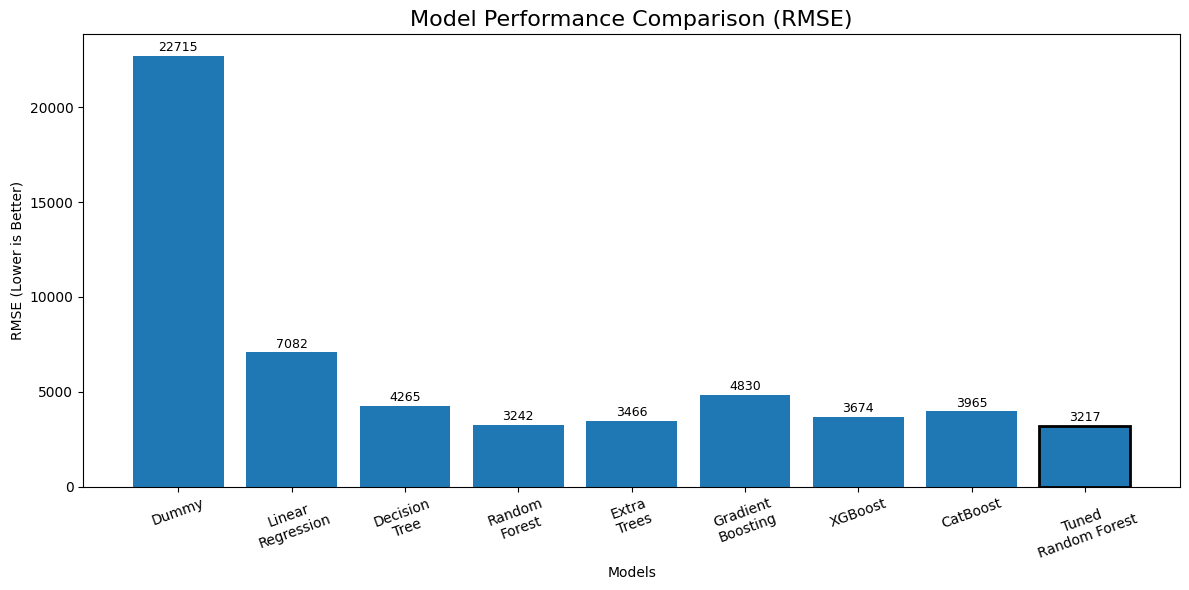

In [1]:
import matplotlib.pyplot as plt

# Model names
models = [
    "Dummy",
    "Linear\nRegression",
    "Decision\nTree",
    "Random\nForest",
    "Extra\nTrees",
    "Gradient\nBoosting",
    "XGBoost",
    "CatBoost",
    "Tuned\nRandom Forest"
]

# RMSE values
rmse = [
    22714.82,
    7082.07,
    4264.85,
    3241.74,
    3466.36,
    4830.26,
    3673.69,
    3965.45,
    3216.55
]

plt.figure(figsize=(12,6))

bars = plt.bar(models, rmse)

# Highlight the best model
bars[-1].set_edgecolor("black")
bars[-1].set_linewidth(2)

plt.title("Model Performance Comparison (RMSE)", fontsize=16)
plt.xlabel("Models")
plt.ylabel("RMSE (Lower is Better)")
plt.xticks(rotation=20)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 250,
        f"{height:.0f}",
        ha='center',
        fontsize=9
    )

plt.tight_layout()

# Save for GitHub README
plt.savefig("model_performance.png", dpi=300, bbox_inches="tight")

plt.show()

# 11. Flight Price Prediction

The trained Random Forest model is used to estimate ticket prices for the unseen test dataset.

In [212]:
final_predictions = final_model.predict(X_test)

print("="*70)
print("Prediction Completed")
print("="*70)

print(final_predictions[:5])

Prediction Completed
[ 4652.49343056 13161.42866865  5163.2515781  58414.32572727
 50211.20710714]


# 12. Feature Importance Analysis

Random Forest provides feature importance scores that indicate how much each feature contributes to the prediction process.

Understanding the importance of each feature helps identify the key factors affecting flight prices and provides valuable business insights.

In [213]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,class,0.883881
8,duration,0.033951
1,flight,0.030604
4,stops,0.015753
9,days_left,0.014295
6,destination,0.010109
2,source,0.005803
5,arrival,0.003030
3,departure,0.002202
0,airline,0.000371


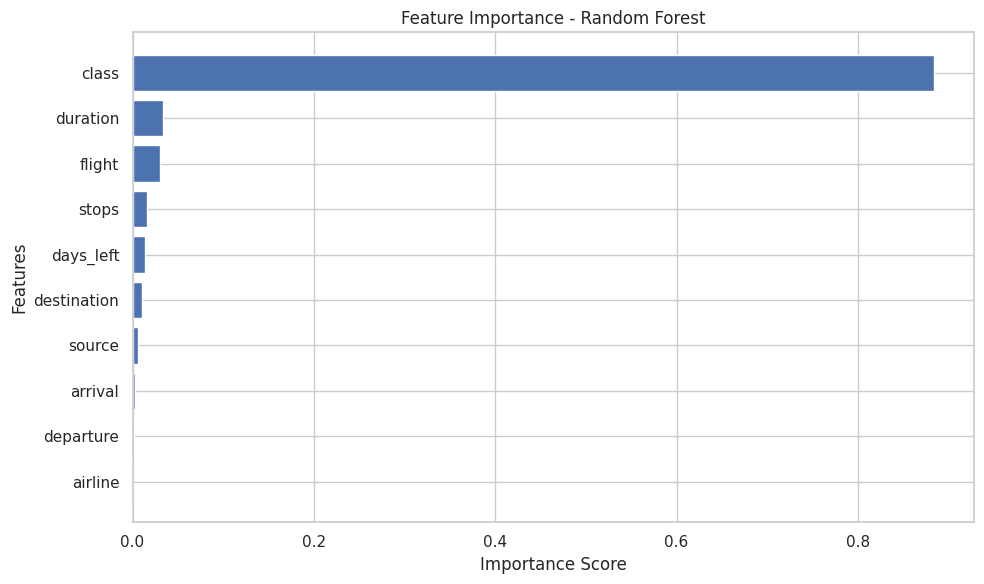

In [214]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance - Random Forest")

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()

### Observation

- The feature importance analysis shows that **travel class** is by far the most influential feature, contributing approximately **88.39%** of the total importance in predicting flight prices.
- **Duration (3.40%)** and **flight number (3.06%)** are the next most important features, indicating that longer journeys and specific flights have a noticeable impact on ticket prices.
- Features such as **stops (1.58%)**, **days_left (1.43%)**, and **destination (1.01%)** contribute moderately to the prediction process.
- **Source, arrival time, departure time, and airline** have relatively low importance, suggesting they contribute less to the model's decisions for this dataset.
- Overall, the Random Forest model relies primarily on the travel class while using the remaining features to refine its predictions.

### Business Insight

The feature importance analysis indicates that **travel class** is the primary driver of flight ticket prices, significantly outweighing all other variables. This suggests that fare differences between Economy and Business classes dominate pricing decisions.

Journey duration and the specific flight also influence ticket prices, while factors such as the number of stops, booking lead time, and destination contribute to a lesser extent.

These insights can help airlines prioritize pricing strategies based on cabin class and route characteristics, while travel platforms can emphasize these factors when providing fare predictions and personalized recommendations.

### Conclusion

Feature importance analysis revealed that the Random Forest model relies predominantly on **travel class** for predicting flight prices, with additional contributions from journey duration, flight identifier, and number of stops. The remaining features provide supplementary information that helps improve prediction accuracy. These findings enhance the interpretability of the model and provide valuable insights into the key factors influencing airfare.

# 13. Submission File Generation

The final model predictions are stored in the required submission format for evaluation.

In [215]:
submission = sample_submission.copy()

submission["price"] = final_predictions

submission.to_csv("submission.csv", index=False)

submission.head()

,id,price
0,0,4652.493431
1,1,13161.428669
2,2,5163.251578
3,3,58414.325727
4,4,50211.207107


In [216]:
print("="*70)
print("Submission Shape")
print("="*70)

print(submission.shape)

print()

print(submission.head())

Submission Shape
(10000, 2)

   id         price
0   0   4652.493431
1   1  13161.428669
2   2   5163.251578
3   3  58414.325727
4   4  50211.207107


In [217]:
submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10000 non-null  int64  
 1   price   10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB


In [218]:
submission.describe()

,id,price
count,10000.00000,10000.000000
mean,4999.50000,20968.360376
std,2886.89568,22642.502338
min,0.00000,1206.602774
25%,2499.75000,5090.844124
50%,4999.50000,7391.606983
75%,7499.25000,43829.693429
max,9999.00000,86583.072587


In [219]:
submission.isnull().sum()

id       0
price    0
dtype: int64

# 14. Project Conclusion

This project developed a machine learning solution for predicting flight ticket prices using historical flight information.

The workflow included data preprocessing, exploratory data analysis, missing value treatment, categorical feature encoding, and the evaluation of multiple regression algorithms, including Dummy Regressor, Linear Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, XGBoost, and CatBoost.

Among all evaluated models, the **Tuned Random Forest Regressor** delivered the strongest overall performance, achieving:

- **MAE:** 1,633.56
- **RMSE:** 3,216.55
- **R² Score:** 0.9799

The selected model explained approximately **97.99%** of the variation in flight ticket prices while maintaining a low prediction error, making it highly suitable for this regression task.

Feature importance analysis further identified the variables that most strongly influence airfare, providing useful insights for airline pricing strategies and revenue optimization.

Overall, the project demonstrates that ensemble tree-based learning methods are highly effective for structured regression problems such as flight price prediction.

# 15. Future Scope

The predictive performance of the model can be further improved through several enhancements:

- Perform more extensive hyperparameter optimization using larger search spaces.
- Incorporate additional flight-related features such as booking date, airline ratings, holiday schedules, and seasonal demand.
- Apply advanced ensemble techniques such as stacking or blending multiple high-performing models.
- Investigate deep learning approaches for large-scale flight pricing datasets.
- Deploy the trained model as a web application or REST API to provide real-time flight price predictions.